# Post-Cavity Experiment â€” Context Mode

Comprehensive characterization using the **qubox_v2 v4** context-mode API
with explicit sample + cooldown scoping.

**Sections:**
1. Setup & Session Initialization
2. OPX/Octave Mixer Calibration
3. Readout Characterization
4. Qubit Characterization
5. Pulse Calibration
6. Readout Calibration
7. SPA Benchmarking
8. Storage Cavity
9. Quantum State Tomography
10. Session Verification & Summary
11. Context Mismatch Protection Demo
12. Utility: Continuous-Wave Output

All calibrations are automatically scoped to the active `sample_id + cooldown_id`.
Stale-calibration reuse across cooldowns is prevented by compatibility checks.

In [1]:
import sys
import numpy as np

# Ensure qubox_v2 is importable from the notebooks/ directory
sys.path.insert(0, r"E:\qubox")

from pathlib import Path
from qualang_tools.units import unit

from qubox_v2.experiments.session import SessionManager
from qubox_v2.experiments import (
    # Spectroscopy
    ResonatorSpectroscopy,
    ResonatorPowerSpectroscopy,
    ResonatorSpectroscopyX180,
    ReadoutTrace,
    QubitSpectroscopy,
    # Time domain
    PowerRabi,
    TemporalRabi,
    T1Relaxation,
    T2Ramsey,
    T2Echo,
    # Calibration
    IQBlob,
    ReadoutGEDiscrimination,
    ReadoutWeightsOptimization,
    ReadoutButterflyMeasurement,
    CalibrateReadoutFull,
    AllXY,
    DRAGCalibration,
    RandomizedBenchmarking,
    PulseTrainCalibration,
    # Cavity / Fock
    StorageSpectroscopy,
    NumSplittingSpectroscopy,
    StorageChiRamsey,
    FockResolvedSpectroscopy,
    FockResolvedT1,
    FockResolvedRamsey,
    FockResolvedPowerRabi,
    # Tomography
    QubitStateTomography,
    StorageWignerTomography,
    SNAPOptimization,
    # SPA
    SPAFluxOptimization,
    SPAPumpFrequencyOptimization,
)
from qubox_v2.experiments.calibration import ReadoutConfig
from qubox_v2.calibration import CalibrationOrchestrator
from qubox_v2.devices import SampleRegistry, SampleInfo
from qubox_v2.core.session_state import SessionState
from qubox_v2.core.artifact_manager import ArtifactManager
from qubox_v2.core.preflight import preflight_check
from qubox_v2.core.artifacts import save_config_snapshot
from qubox_v2.core.schemas import validate_config_dir

u = unit()

2026-02-25 00:51:26,326 - qm - INFO     - Starting session: 279dbe7d-c743-41e1-9add-5f2138621c42


## 1. Setup & Session Initialization

Idempotent setup: create or verify the sample and cooldown in the registry,
open a context-mode `SessionManager`, connect to QM hardware, and run
preflight checks.

**Directory layout:**
```
samples/<sample_id>/
  sample.json
  config/  (hardware.json, cqed_params.json, devices.json, pulse_specs.json)
  cooldowns/<cooldown_id>/
    config/  (calibration.json, pulses.json, measureConfig.json)
    data/
    artifacts/
```

In [2]:
# â”€â”€ Registry, Sample & Cooldown â”€â”€
REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2025_02_22"

registry = SampleRegistry(REGISTRY_BASE)

if not registry.sample_exists(SAMPLE_ID):
    registry.create_sample(
        SAMPLE_ID,
        description="Transmon qubit A â€” 3D cavity sample",
        config_source=Path(r"E:\qubox\seq_1_device\config"),
        metadata={"chip": "Q1-2025A", "fridge": "BlueFors-LD400"},
    )
    print(f"Created sample '{SAMPLE_ID}'")
else:
    print(f"Sample '{SAMPLE_ID}' exists")

if not registry.cooldown_exists(SAMPLE_ID, COOLDOWN_ID):
    registry.create_cooldown(
        SAMPLE_ID, COOLDOWN_ID,
        seed_from=Path(r"E:\qubox\seq_1_device\config"),
    )
    print(f"Created cooldown '{COOLDOWN_ID}'")
else:
    print(f"Cooldown '{COOLDOWN_ID}' exists")

info = registry.load_sample_info(SAMPLE_ID)
print(f"Sample: {info.sample_id} â€” {info.description}")
print(f"Cooldowns: {registry.list_cooldowns(SAMPLE_ID)}")

# â”€â”€ Session â”€â”€
session = SessionManager(
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    registry_base=REGISTRY_BASE,
    qop_ip="10.157.36.68",
    cluster_name="Cluster_2",
    auto_save_calibration=True,
)
session.open()

ctx = session.context
attr = session.attributes
print(f"\nContext: sample={ctx.sample_id}  cooldown={ctx.cooldown_id}  wiring={ctx.wiring_rev}")
print(f"Config hash: {ctx.config_hash}  Schema: {ctx.schema_version}")
print(f"Experiment path: {session.experiment_path}")
print(f"Resonator: {attr.ro_fq / 1e9:.4f} GHz")
print(f"Qubit:     {attr.qb_fq / 1e9:.4f} GHz")
print(f"Storage:   {attr.st_fq / 1e9:.4f} GHz")

cal_ctx = session.calibration.data.context
if cal_ctx:
    print(f"\nCalibration bound to sample={cal_ctx.sample_id} cooldown={cal_ctx.cooldown_id}")
else:
    print("\nNo context block in calibration (legacy v3 â€” will be stamped on first save)")

# Uncomment to run in simulation mode:
# session.hw.set_exec_mode("simulate")

Sample 'post_cavity_sample_A' exists
Cooldown 'cd_2025_02_22' exists
Sample: post_cavity_sample_A â€” Transmon qubit A — 3D cavity sample
Cooldowns: ['cd_2025_02_22']
[INFO] 2026-02-25 00:51:28,148 qubox.devices.context_resolver: Resolved context: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=46159a85
[INFO] 2026-02-25 00:51:28,149 qubox.experiments.session: Context mode: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=46159a85
[INFO] 2026-02-25 00:51:28,149 qubox.experiments.session: SessionManager initialising at E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22
2026-02-25 00:51:31,857 - qm - INFO     - Performing health check
2026-02-25 00:51:31,861 - qm - INFO     - Health check passed
[INFO] 2026-02-25 00:51:31,873 qubox.calibration.store: Loading calibration from E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[WARNING] 2026-02-25 00:51:31,876 qubox.calibration.store: Calibration file has no context block (le

Deprecated cqed_params keys loaded for backward compatibility: ['ro_therm_clks', 'qb_therm_clks', 'st_therm_clks', 'b_coherent_amp', 'b_coherent_len', 'b_alpha']


[INFO] 2026-02-25 00:51:34,668 qubox.experiments.session: SessionManager ready.
2026-02-25 00:51:36,070 - qm - WARNING  - Open QM ended with warning 0: Opening a new Quantum Machine and closing Quantum Machines: 
2026-02-25 00:51:36,070 - qm - WARNING  - Open QM ended with warning 0: Quantum Machine qm-1772001219446 is canceling running job 1771622594161.
[INFO] 2026-02-25 00:51:36,300 qubox.experiments.session: Loaded measureMacro state from E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\measureConfig.json
[INFO] 2026-02-25 00:51:36,301 qubox.experiments.session: Synced measureMacro from CalibrationStore (element=resonator)
[INFO] 2026-02-25 00:51:36,301 qubox.experiments.session: Runtime element validation: available=['qubit', 'qubit2', 'resonator', 'resonator2', 'storage']

Context: sample=post_cavity_sample_A  cooldown=cd_2025_02_22  wiring=46159a85
Config hash: a39aaac2ac4f  Schema: 4.0.0
Experiment path: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_202

### 1.1 Session Snapshot & Preflight Validation

Build an immutable `SessionState` snapshot (SHA-256 build hash), run preflight
validation, save a config snapshot artifact, and validate JSON schemas.

In [3]:
orch = CalibrationOrchestrator(session)

config_dir = Path(session.experiment_path) / "config"
sample_config_dir = getattr(session, "_sample_config_dir", None)
ss = SessionState.from_config_dir(
    config_dir,
    sample_config_dir=sample_config_dir,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    wiring_rev=ctx.wiring_rev,
)
am = ArtifactManager(session.experiment_path, ss.build_hash)
am.save_session_state(ss.to_dict())
print(ss.summary())
print(f"\nArtifacts root: {am.root}")

# Preflight validation
report = preflight_check(session)
if report["all_ok"]:
    print("All preflight checks PASSED.")
else:
    print("PREFLIGHT FAILURES:")
    for err in report["errors"]:
        print(f"  - {err}")

if report["warnings"]:
    print("Warnings:")
    for w in report["warnings"]:
        print(f"  - {w}")

snapshot_path = save_config_snapshot(session, tag="session_open")
print(f"\nConfig snapshot saved to: {snapshot_path}")

schema_results = validate_config_dir(config_dir)
print("\nSchema validation:")
for r in schema_results:
    status = "PASS" if r.valid else "FAIL"
    print(f"  {status} v={r.version}")
    for e in r.errors:
        print(f"    ERROR: {e}")
    for w in r.warnings:
        print(f"    WARN: {w}")

SessionState (build_hash=0351c6afe7d4)
  timestamp: 2026-02-25T00:51:36.355914
  git_commit: 9bb869727661
  sample_id: post_cavity_sample_A
  cooldown_id: cd_2025_02_22
  wiring_rev: 46159a85
  schemas:
    hardware: v1 (5133 bytes) — E:\qubox\samples\post_cavity_sample_A\config\hardware.json
    calibration: v4.0.0 (2076 bytes) — E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
    pulses: v2 (969116 bytes) — E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json
  hardware elements: ['resonator', 'resonator2', 'qubit2', 'qubit', 'storage']
  calibration sections: ['discrimination', 'readout_quality', 'frequencies', 'coherence', 'pulse_calibrations']
  pulse specs: 1 definitions

Artifacts root: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\artifacts\0351c6afe7d4
All preflight checks PASSED.

Config snapshot saved to: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\artifacts\config_snapshot_se

### 1.2 Readout Override

Configure which readout element, operation, demodulation method, and weights
are used by `measureMacro` for all subsequent experiments.

**Inputs:** element, operation, weights, demod method, threshold, weight length
**Outputs:** Updated `measureMacro` state, persisted `measureConfig.json`

In [ ]:
READOUT_OVERRIDE_ELEMENT = attr.ro_el
READOUT_OVERRIDE_OP = "readout"
READOUT_OVERRIDE_WEIGHTS = None
READOUT_OVERRIDE_DEMOD = "dual_demod.full"
READOUT_OVERRIDE_THRESHOLD = None
READOUT_OVERRIDE_WEIGHT_LEN = None

override_info = session.override_readout_operation(
    element=READOUT_OVERRIDE_ELEMENT,
    operation=READOUT_OVERRIDE_OP,
    weights=READOUT_OVERRIDE_WEIGHTS,
    demod=READOUT_OVERRIDE_DEMOD,
    threshold=READOUT_OVERRIDE_THRESHOLD,
    weight_len=READOUT_OVERRIDE_WEIGHT_LEN,
    apply_to_attributes=True,
    persist_measure_config=True,
    drive_frequency=attr.ro_fq,
)

print("Readout override applied:")
print(f"  element:    {override_info['element']}")
print(f"  operation:  {override_info['operation']}")
print(f"  pulse:      {override_info['pulse']}")
print(f"  ro_el:      {override_info['attributes_ro_el']}")
print(f"  QM mapping: {override_info['qm_config_entry']}")
print(f"  persisted:  {override_info['measure_config_path']}")

### 1.3 Readout Internal Pulse Override (Square WF)

Directly modify the internal readout pulse waveforms and pulse length in the pulse manager.
Use this when you want to change the actual emitted readout envelope (not only `measureMacro` mapping).

**NEEDS_RUN**: Re-burns and saves pulses to the cooldown-scoped pulse store.

In [ ]:
# --- Readout internal pulse override (square + ringdown) ---
READOUT_WF_ENABLE = True

RO_INTERNAL_ELEMENT = attr.ro_el
RO_INTERNAL_OP = "readout"

RO_PULSE_LEN = 256
RO_RINGDOWN_LEN = 144
RO_TOTAL_LEN = int(RO_PULSE_LEN + RO_RINGDOWN_LEN)
RO_AMP = 0.04

if READOUT_WF_ENABLE:
    pm = session.pulse_mgr
    pulse_info = pm.get_pulseOp_by_element_op(RO_INTERNAL_ELEMENT, RO_INTERNAL_OP, strict=False)
    if pulse_info is None:
        raise RuntimeError(
            f"No pulse mapping found for element='{RO_INTERNAL_ELEMENT}', op='{RO_INTERNAL_OP}'."
        )

    ro_pulse = pulse_info.pulse
    i_wf_name = pulse_info.I_wf_name
    q_wf_name = pulse_info.Q_wf_name

    if not i_wf_name or not q_wf_name:
        raise RuntimeError(
            f"Readout pulse '{ro_pulse}' is missing I/Q waveform names (I={i_wf_name}, Q={q_wf_name})."
        )

    i_wf = np.zeros(RO_TOTAL_LEN, dtype=float)
    q_wf = np.zeros(RO_TOTAL_LEN, dtype=float)
    i_wf[:RO_PULSE_LEN] = float(RO_AMP)

    pm.modify_waveform(i_wf_name, i_wf, persist=True, allow_type_change=True)
    pm.modify_waveform(q_wf_name, q_wf, persist=True, allow_type_change=True)
    pm.modify_pulse(ro_pulse, new_length=RO_TOTAL_LEN, persist=True)

    session.burn_pulses()
    session.save_pulses()

    print("Readout internal waveform override applied:")
    print(f"  element/op : {RO_INTERNAL_ELEMENT}/{RO_INTERNAL_OP}")
    print(f"  pulse      : {ro_pulse}")
    print(f"  I waveform : {i_wf_name} (square @ {RO_AMP:.6f}, len={RO_PULSE_LEN})")
    print(f"  Q waveform : {q_wf_name} (zero, len={RO_TOTAL_LEN})")
    print(f"  pulse len  : {RO_TOTAL_LEN} samples ({RO_PULSE_LEN} + {RO_RINGDOWN_LEN})")
else:
    print("READOUT_WF_ENABLE is False; no waveform modifications applied.")

[INFO] 2026-02-25 00:24:54,169 qubox.experiments.session: Saved pulse manager state to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json
Readout internal waveform override applied:
  element/op : resonator/readout
  pulse      : readout_pulse
  I waveform : readout_I_wf (square @ 0.035000, len=256)
  Q waveform : readout_Q_wf (zero, len=400)
  pulse len  : 400 samples (256 + 144)


## 2. OPX/Octave Mixer Calibration

Calibrate IQ mixer offsets (DC offset, gain imbalance, phase imbalance) for
each element. Two paths are provided:

- **3.0 Auto Calibration** â€” QM/Octave built-in calibration (recommended first pass)
- **3.1 Manual Calibration** â€” SA124B-driven grid search or minimizer for fine-tuning

Run at least one path before any measurements to ensure clean signal generation.

### 2.0 Auto Calibration (Octave Built-in)

Uses QM's built-in Octave mixer calibration for all active elements.
Optionally validates results with a post-calibration SA measurement.

**NEEDS_RUN**: Requires QOP connection and Octave hardware.

In [7]:
hw = session.hw

# Optional LO overrides (set APPLY_LO_OVERRIDES=True to enable)
APPLY_LO_OVERRIDES = True
PERSIST_LO_OVERRIDES = True
LO_GAIN_OVERRIDE_DB = None                 # global fallback (dB)
EXTERNAL_LO_POWER_OVERRIDE_DBM = None      # e.g. 13.0 (external-LO elements only)
LO_GAIN_OVERRIDE_MAP = {}     # per-element gain override (dB)
EXTERNAL_LO_POWER_OVERRIDE_MAP = {}        # Optional per-element external-LO power override

elements = hw.get_active_mixer_elements()
if not elements:
    raise RuntimeError("No active mixer elements found in live QM config.")

el_los = hw.get_element_lo(elements)
el_ifs = hw.get_element_if(elements)

print("Mixer calibration targets (active elements):")
for el, lo, if_fq in zip(elements, el_los, el_ifs):
    print(f"  {el:20s}  LO={lo/1e9:.4f} GHz  IF={if_fq/1e6:.2f} MHz")

applied_gain = {}
applied_ext_lo_power = {}

if APPLY_LO_OVERRIDES:
    for el in elements:
        gain_db = LO_GAIN_OVERRIDE_MAP.get(el, LO_GAIN_OVERRIDE_DB)
        if gain_db is not None:
            gain_db = float(gain_db)
            hw.set_octave_gain(el, gain_db)

            rf_out = hw._element_octave_rf_out(el) if hasattr(hw, "_element_octave_rf_out") else None
            if rf_out is not None:
                oct_name, rf_port = rf_out
                session.config_engine.hw_set_octave_rf_output(
                    octave=oct_name,
                    rf_out=int(rf_port),
                    gain=gain_db,
                )
            applied_gain[el] = gain_db

        pwr_dbm = EXTERNAL_LO_POWER_OVERRIDE_MAP.get(el, EXTERNAL_LO_POWER_OVERRIDE_DBM)
        if pwr_dbm is not None:
            pwr_dbm = float(pwr_dbm)
            try:
                hw.set_external_lo_power(el, pwr_dbm)
                applied_ext_lo_power[el] = pwr_dbm
            except Exception as exc:
                print(f"[warn] Skipping external LO power override for {el}: {exc}")

    if applied_ext_lo_power:
        def _patch_external_lo_power(hw_base, hw_extras):
            qubox = hw_extras.setdefault("__qubox", {})
            if not isinstance(qubox, dict):
                qubox = {}
                hw_extras["__qubox"] = qubox
            power_map = qubox.setdefault("external_lo_power_dbm", {})
            for name, value in applied_ext_lo_power.items():
                power_map[str(name)] = float(value)

        session.config_engine.patch_hardware(_patch_external_lo_power)

    if PERSIST_LO_OVERRIDES and (applied_gain or applied_ext_lo_power):
        session.config_engine.save_hardware()

    if applied_gain:
        print("\nApplied LO gain overrides (dB):")
        for el, val in applied_gain.items():
            print(f"  {el:20s}  gain={val:.2f}")
    if applied_ext_lo_power:
        print("\nApplied external LO power overrides (dBm):")
        for el, val in applied_ext_lo_power.items():
            print(f"  {el:20s}  power={val:.2f}")
    if PERSIST_LO_OVERRIDES and (applied_gain or applied_ext_lo_power):
        print("Persisted LO override updates to hardware.json and devices.json (when external LO was applied).")

# --- Auto calibration (Octave built-in) ---
auto_results = hw.calibrate_element(
    el=None,
    method="auto",
    save_to_db=True,
    auto_sa_validate=True,
    auto_sa_device_name="sa124b",
)

print("\nAuto calibration complete.")
if hasattr(auto_results, "__iter__") and not isinstance(auto_results, (str, bytes, dict)):
    for r in auto_results:
        print(f"  {r}")
else:
    print(f"  {auto_results}")

Mixer calibration targets (active elements):
  qubit                 LO=6.2000 GHz  IF=-49.64 MHz
  storage               LO=5.4000 GHz  IF=-50.00 MHz
  resonator2            LO=3.5000 GHz  IF=-50.00 MHz
  qubit2                LO=7.0000 GHz  IF=-50.00 MHz
  resonator             LO=8.8000 GHz  IF=-203.78 MHz
2026-02-25 00:26:07,164 - qm - INFO     - Compiling program
2026-02-25 00:26:13,567 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:26:13,594 - qm - INFO     - Executing program
2026-02-25 00:26:17,818 - qm - INFO     - Compiling program
2026-02-25 00:26:24,340 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:26:24,369 - qm - INFO     - Executing program
2026-02-25 00:26:28,604 - qm - INFO     - Compiling program
2026-02-25 00:26:34,815 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:26:34,852 - qm - INFO     - Executing program
2026-02-25 00:26:39,537 - qm - INFO     - Compiling program


Auto calibration warning for 'qubit2': invalid value encountered in sqrt
Auto calibration considered FAILED for 'qubit2' (reasons=runtime_warning).


2026-02-25 00:26:44,508 - qm - INFO     - Compiling program
2026-02-25 00:26:50,531 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:26:50,560 - qm - INFO     - Executing program


Auto mixer calibration finished with failures for element(s): qubit2.



Auto mixer SA validation report (CW post-check):
Element               LO(dBc)   IRR(dBc)   Ptarget(dBm)
qubit                   59.93      32.89         -26.06
storage                 48.89      41.49         -25.73
resonator2              47.33      33.73         -30.17
resonator               46.74      46.23         -38.70
Auto mixer calibration finished with failures for element(s): qubit2.
  - element calibration failed: qubit2 (reasons=runtime_warning)

Auto calibration complete.
  None


### 2.1 Manual Calibration UX Controls

Configure logging, scan bounds/grid, spectrum analyser settings, and sideband
objective for the manual IQ calibration path. Skip to Section 4 if auto-cal
results are satisfactory.

**NEEDS_RUN**: Only needed when manual refinement is required.

In [3]:
# -------- Notebook-level UX toggles --------
QUIET_QM_LOGS = True
LIVE_PLOTS = True
LIVE_PLOT_EVERY = 1

# -------- Scan bounds / grid --------
DC_COARSE_RANGE = 0.10
DC_COARSE_N = 11
DC_FINE_RANGE = 0.02
DC_FINE_N = 11

IQ_GAIN_RANGE = 0.10
IQ_PHASE_RANGE = 0.20
IQ_COARSE_N = 11
IQ_FINE_GAIN_RANGE = 0.02
IQ_FINE_PHASE_RANGE = 0.04
IQ_FINE_N = 11

MIN_MAXITER = 40
MIN_XTOL = 1e-4

# -------- Spectrum analyzer settings --------
SA_SPAN_HZ = 1e6
SA_RBW = 5e3
SA_VBW = 5e3
SA_LEVEL_DBM = 0.0
SA_AVG = 2
SA_SETTLE_S = 0.0
SA_EXTRA_CONFIG = {}

# -------- Sideband targeting objective --------
SIDEBAND = "lsb"
OBJECTIVE_MODE = "weighted_sum"
W_CARRIER = 1.0
W_IMAGE = 1.0
W_TARGET = 1.0

print("Manual calibration controls set.")

Manual calibration controls set.


### 2.2 Manual IQ Calibration Run

Run the SA124B-driven manual mixer calibration for all active mixer elements.
Compares before/after LO leakage, image rejection, and target sideband power
for each element.

**NEEDS_RUN**: Requires SA124B spectrum analyser and QOP connection.

In [4]:
print("Manual calibration flow: each element runs auto reference calibration first, then manual minimizer starts from the auto-calibrated correction matrix values.")

Manual calibration flow: each element runs auto reference calibration first, then manual minimizer starts from the auto-calibrated correction matrix values.



Manual calibration complete for all active elements.


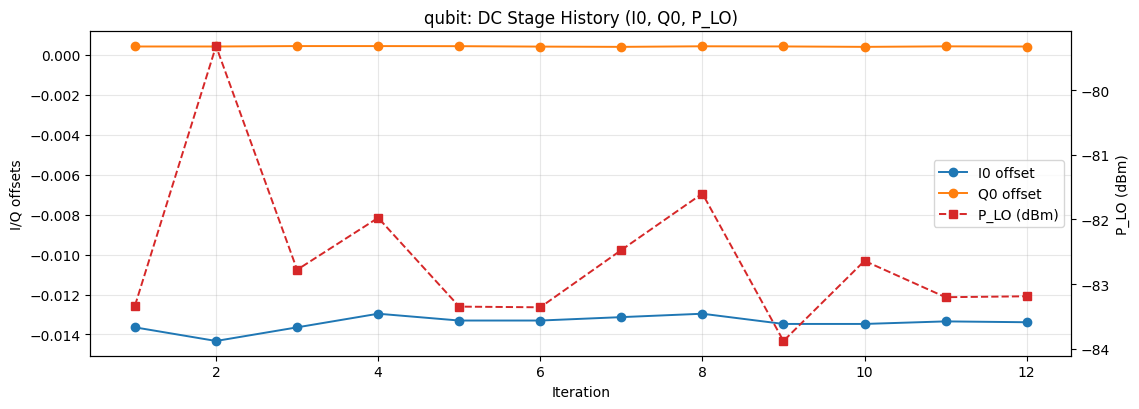

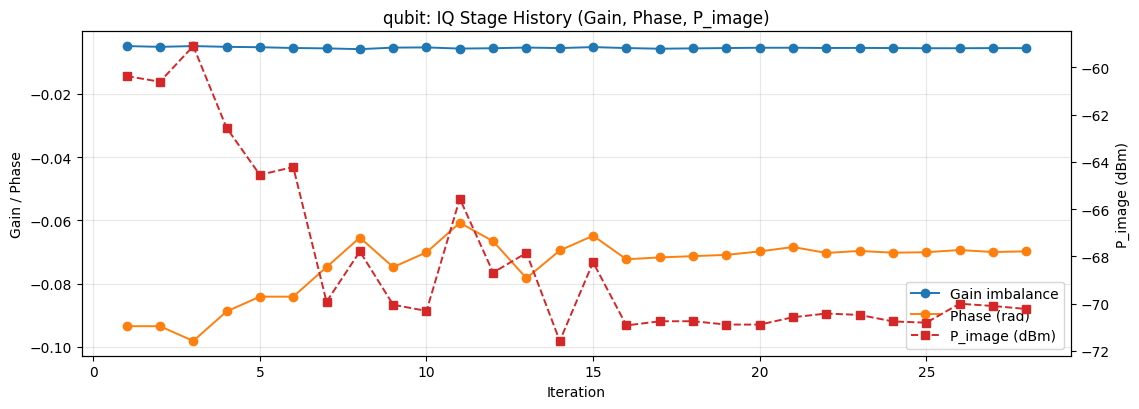

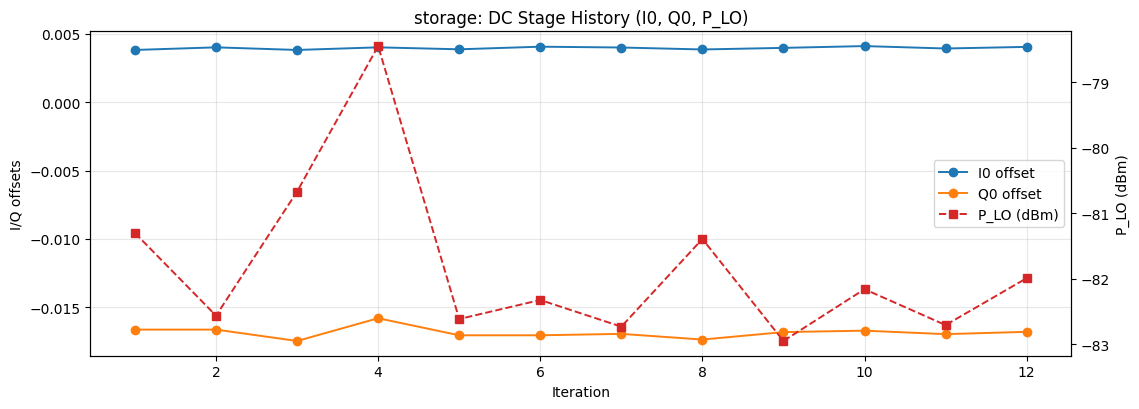

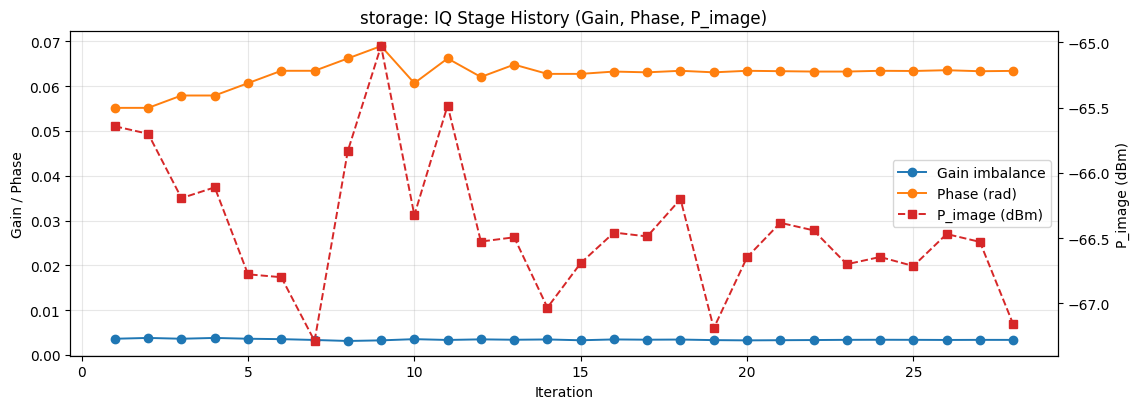

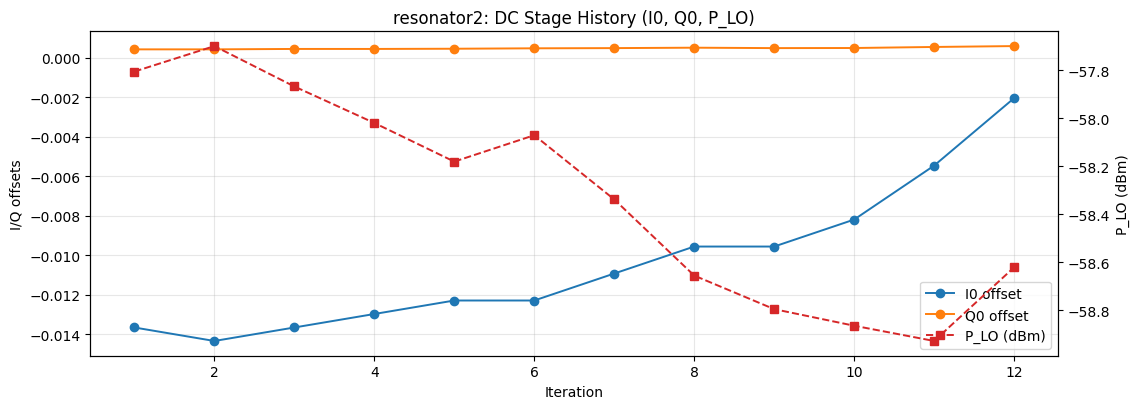

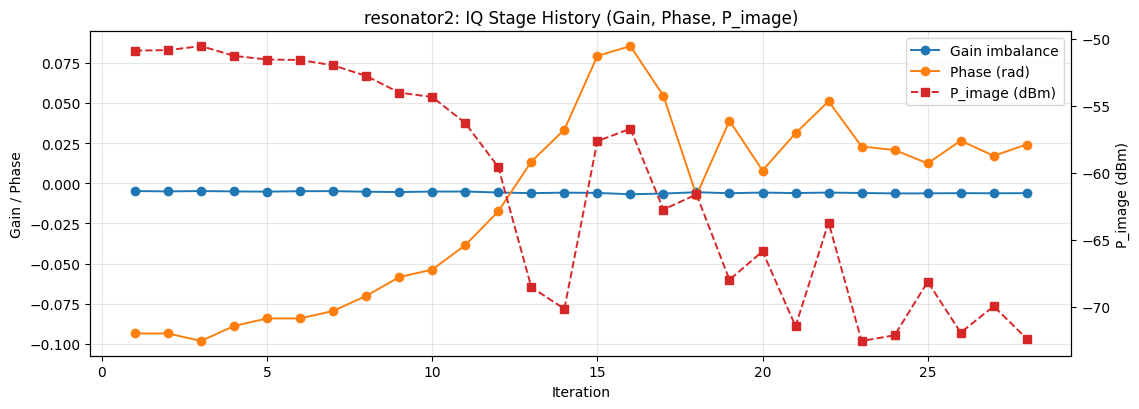

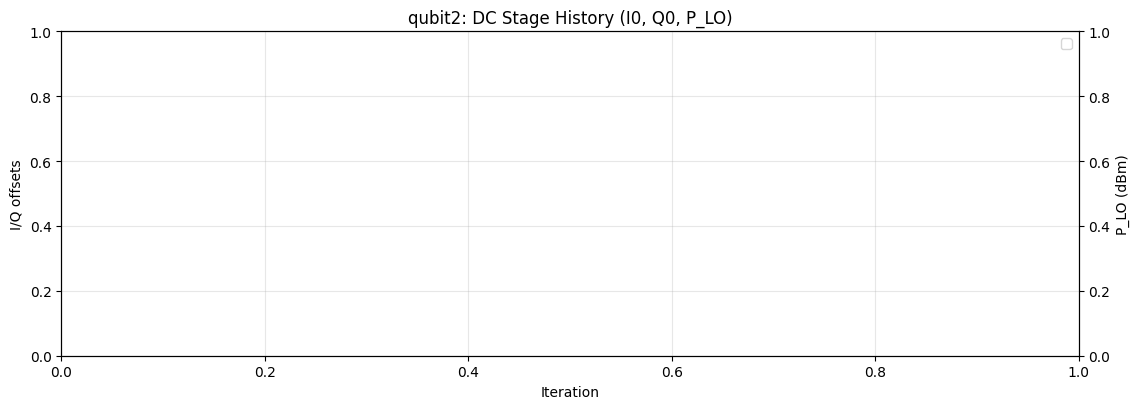

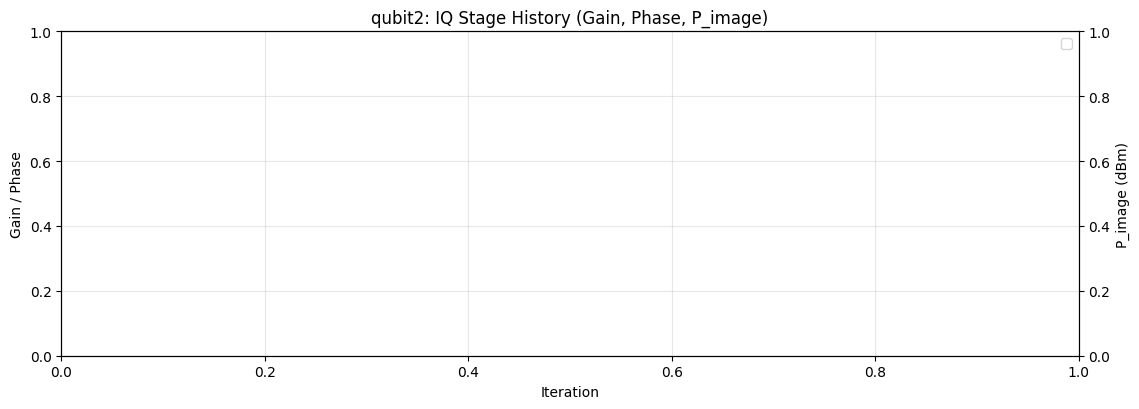

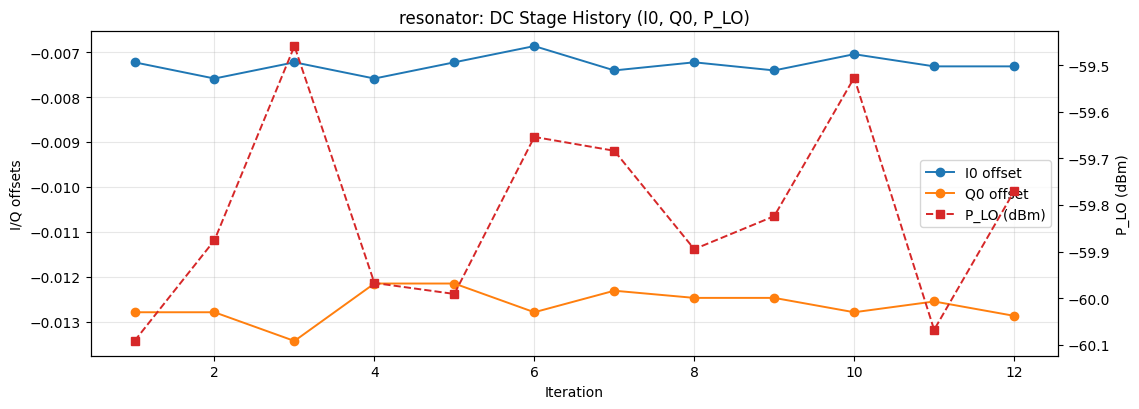

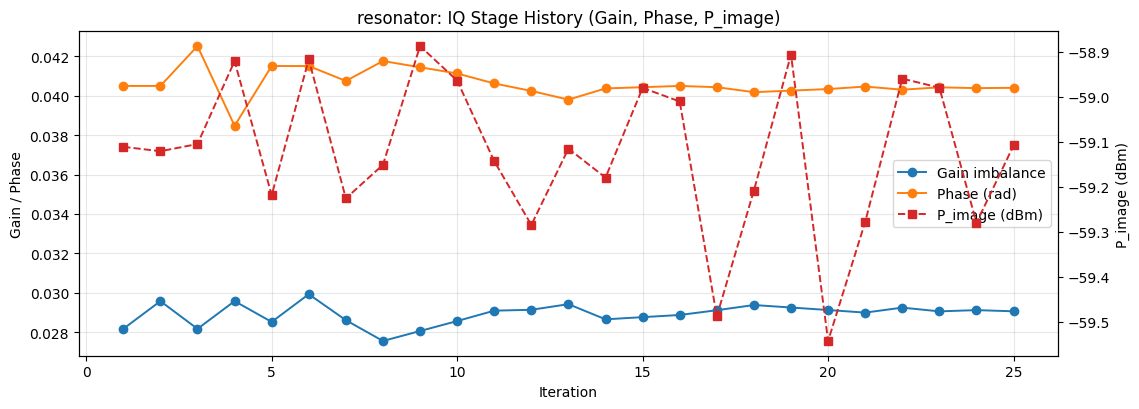


Suppression summary per element (powers in dBm, ratios are linear factors):

----------------------------------------------------------------------------------------------------------------------------------
Element: qubit
  Target sideband power (before/after):       -26.93 ->       -26.95
  LO power (before/after):                    -83.10 ->       -83.41
  Image sideband power (before/after):        -60.47 ->       -70.27
  Target/LO ratio factor (before/after):        4.139e+05 ->      4.420e+05  (x1.068e+00)
  Target/Image ratio factor (before/after):     2.256e+03 ->      2.146e+04  (x9.514e+00)

----------------------------------------------------------------------------------------------------------------------------------
Element: storage
  Target sideband power (before/after):       -26.50 ->       -26.51
  LO power (before/after):                    -75.27 ->       -76.00
  Image sideband power (before/after):        -65.43 ->       -65.61
  Target/LO ratio factor (before/

In [5]:
hw = session.hw

elements = hw.get_active_mixer_elements()
if not elements:
    raise RuntimeError("No active mixer elements found in live QM config.")

el_los = hw.get_element_lo(elements)
el_ifs = hw.get_element_if(elements)

print("Mixer calibration targets (active elements):")
for el, lo, if_fq in zip(elements, el_los, el_ifs):
    print(f"  {el:20s}  LO={lo/1e9:.4f} GHz  IF={if_fq/1e6:.2f} MHz")

# Optional LO overrides (set APPLY_LO_OVERRIDES=True to enable)
APPLY_LO_OVERRIDES = True
PERSIST_LO_OVERRIDES = True
LO_GAIN_OVERRIDE_DB = None                 # global fallback (dB)
EXTERNAL_LO_POWER_OVERRIDE_DBM = None      # e.g. 13.0 (external-LO elements only)
LO_GAIN_OVERRIDE_MAP = {"qubit": 2.0}     # per-element gain override (dB)
EXTERNAL_LO_POWER_OVERRIDE_MAP = {}        # Optional per-element external-LO power override

applied_gain = {}
applied_ext_lo_power = {}

if APPLY_LO_OVERRIDES:
    for el in elements:
        gain_db = LO_GAIN_OVERRIDE_MAP.get(el, LO_GAIN_OVERRIDE_DB)
        if gain_db is not None:
            gain_db = float(gain_db)
            hw.set_octave_gain(el, gain_db)

            rf_out = hw._element_octave_rf_out(el) if hasattr(hw, "_element_octave_rf_out") else None
            if rf_out is not None:
                oct_name, rf_port = rf_out
                session.config_engine.hw_set_octave_rf_output(
                    octave=oct_name,
                    rf_out=int(rf_port),
                    gain=gain_db,
                )
            applied_gain[el] = gain_db

        pwr_dbm = EXTERNAL_LO_POWER_OVERRIDE_MAP.get(el, EXTERNAL_LO_POWER_OVERRIDE_DBM)
        if pwr_dbm is not None:
            pwr_dbm = float(pwr_dbm)
            try:
                hw.set_external_lo_power(el, pwr_dbm)
                applied_ext_lo_power[el] = pwr_dbm
            except Exception as exc:
                print(f"[warn] Skipping external LO power override for {el}: {exc}")

    if applied_ext_lo_power:
        def _patch_external_lo_power(hw_base, hw_extras):
            qubox = hw_extras.setdefault("__qubox", {})
            if not isinstance(qubox, dict):
                qubox = {}
                hw_extras["__qubox"] = qubox
            power_map = qubox.setdefault("external_lo_power_dbm", {})
            for name, value in applied_ext_lo_power.items():
                power_map[str(name)] = float(value)

        session.config_engine.patch_hardware(_patch_external_lo_power)

    if PERSIST_LO_OVERRIDES and (applied_gain or applied_ext_lo_power):
        session.config_engine.save_hardware()

    if applied_gain:
        print("\nApplied LO gain overrides (dB):")
        for el, val in applied_gain.items():
            print(f"  {el:20s}  gain={val:.2f}")
    if applied_ext_lo_power:
        print("\nApplied external LO power overrides (dBm):")
        for el, val in applied_ext_lo_power.items():
            print(f"  {el:20s}  power={val:.2f}")
    if PERSIST_LO_OVERRIDES and (applied_gain or applied_ext_lo_power):
        print("Persisted LO override updates to hardware.json and devices.json (when external LO was applied).")

# --- Manual IQ mixer calibration via SA124B ---
from qubox_v2.calibration import MixerCalibrationConfig
from IPython.display import clear_output
import matplotlib.pyplot as plt

cfg = MixerCalibrationConfig(
    sa_span_hz=SA_SPAN_HZ, sa_rbw=SA_RBW, sa_vbw=SA_VBW,
    sa_level=SA_LEVEL_DBM, sa_avg=SA_AVG, sa_settle=SA_SETTLE_S,
    sa_extra_config=SA_EXTRA_CONFIG,
    dc_coarse_range=DC_COARSE_RANGE, dc_coarse_n=DC_COARSE_N,
    dc_fine_range=DC_FINE_RANGE, dc_fine_n=DC_FINE_N,
    iq_gain_range=IQ_GAIN_RANGE, iq_phase_range=IQ_PHASE_RANGE,
    iq_coarse_n=IQ_COARSE_N,
    iq_fine_range_gain=IQ_FINE_GAIN_RANGE,
    iq_fine_range_phase=IQ_FINE_PHASE_RANGE,
    iq_fine_n=IQ_FINE_N,
    minimizer_maxiter=MIN_MAXITER, minimizer_xtol=MIN_XTOL,
    quiet_qm_logs=QUIET_QM_LOGS, live_plot=LIVE_PLOTS,
    live_plot_every=LIVE_PLOT_EVERY,
    sideband=SIDEBAND, objective_mode=OBJECTIVE_MODE,
    w_carrier=W_CARRIER, w_image=W_IMAGE, w_target=W_TARGET,
)

manual_results = []
for target_el, target_lo, target_if in zip(elements, el_los, el_ifs):
    target_lo = float(target_lo)
    target_if = float(target_if)

    print(f"\nCalibrating '{target_el}'...")
    result = hw.calibrate_element(
        el=target_el, method="manual_minimizer",
        mixer_cal_config=cfg, save_to_db=False,
    )
    manual_results.append(result)

clear_output(wait=True)
print("\nManual calibration complete for all active elements.")

# --- Final plotting: combined history plots (per element) ---
for result in manual_results:
    el = result.get("element", "unknown")
    dc_hist = result.get("dc_history") or {}
    iq_hist = result.get("iq_history") or {}

    i0_hist = list(dc_hist.get("i0", []))
    q0_hist = list(dc_hist.get("q0", []))
    p_lo_hist = list(dc_hist.get("p_lo_dbm", []))

    gain_hist = list(iq_hist.get("gain", []))
    phase_hist = list(iq_hist.get("phase", []))
    p_img_hist = list(iq_hist.get("p_image_dbm", []))

    # DC history: I0, Q0 and P_LO on same plot (dual y-axis)
    fig, ax_left = plt.subplots(figsize=(11.5, 4.2))
    x_dc = range(1, max(len(i0_hist), len(q0_hist), len(p_lo_hist)) + 1)

    if i0_hist:
        ax_left.plot(range(1, len(i0_hist) + 1), i0_hist, "o-", lw=1.4, label="I0 offset")
    if q0_hist:
        ax_left.plot(range(1, len(q0_hist) + 1), q0_hist, "o-", lw=1.4, label="Q0 offset")
    ax_left.set_xlabel("Iteration")
    ax_left.set_ylabel("I/Q offsets")
    ax_left.grid(alpha=0.3)

    ax_right = ax_left.twinx()
    if p_lo_hist:
        ax_right.plot(range(1, len(p_lo_hist) + 1), p_lo_hist, "s--", lw=1.4, color="tab:red", label="P_LO (dBm)")
    ax_right.set_ylabel("P_LO (dBm)")

    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")
    ax_left.set_title(f"{el}: DC Stage History (I0, Q0, P_LO)")
    plt.tight_layout()
    plt.show()

    # IQ history: gain, phase and P_image on same plot (dual y-axis)
    fig, ax_left = plt.subplots(figsize=(11.5, 4.2))
    x_iq = range(1, max(len(gain_hist), len(phase_hist), len(p_img_hist)) + 1)

    if gain_hist:
        ax_left.plot(range(1, len(gain_hist) + 1), gain_hist, "o-", lw=1.4, label="Gain imbalance")
    if phase_hist:
        ax_left.plot(range(1, len(phase_hist) + 1), phase_hist, "o-", lw=1.4, label="Phase (rad)")
    ax_left.set_xlabel("Iteration")
    ax_left.set_ylabel("Gain / Phase")
    ax_left.grid(alpha=0.3)

    ax_right = ax_left.twinx()
    if p_img_hist:
        ax_right.plot(range(1, len(p_img_hist) + 1), p_img_hist, "s--", lw=1.4, color="tab:red", label="P_image (dBm)")
    ax_right.set_ylabel("P_image (dBm)")

    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")
    ax_left.set_title(f"{el}: IQ Stage History (Gain, Phase, P_image)")
    plt.tight_layout()
    plt.show()

# --- Extensive suppression printout / table ---
def _safe_float(v):
    try:
        return float(v)
    except Exception:
        return float("nan")

def _ratio_factor(p_target_dbm, p_unwanted_dbm):
    if (p_target_dbm != p_target_dbm) or (p_unwanted_dbm != p_unwanted_dbm):
        return float("nan")
    return 10.0 ** ((p_target_dbm - p_unwanted_dbm) / 10.0)

def _fmt(v, width=12, prec=2):
    if v != v:
        return f"{'nan':>{width}s}"
    return f"{v:>{width}.{prec}f}"

def _fmt_ratio(v, width=14):
    if v != v:
        return f"{'nan':>{width}s}"
    return f"{v:>{width}.3e}"

table_rows = []
for result in manual_results:
    el = str(result.get("element", "unknown"))
    baseline = result.get("baseline_before_manual", {}) or {}

    p_t_before = _safe_float(baseline.get("P_des_dBm"))
    p_lo_before = _safe_float(baseline.get("P_LO_dBm"))
    p_img_before = _safe_float(baseline.get("P_img_dBm"))

    p_t_after = _safe_float(result.get("P_des_dBm"))
    p_lo_after = _safe_float(result.get("P_LO_dBm"))
    p_img_after = _safe_float(result.get("P_img_dBm"))

    ratio_t_lo_before = _ratio_factor(p_t_before, p_lo_before)
    ratio_t_img_before = _ratio_factor(p_t_before, p_img_before)
    ratio_t_lo_after = _ratio_factor(p_t_after, p_lo_after)
    ratio_t_img_after = _ratio_factor(p_t_after, p_img_after)

    table_rows.append({
        "element": el,
        "P_t_before": p_t_before,
        "P_lo_before": p_lo_before,
        "P_img_before": p_img_before,
        "R_t_lo_before": ratio_t_lo_before,
        "R_t_img_before": ratio_t_img_before,
        "P_t_after": p_t_after,
        "P_lo_after": p_lo_after,
        "P_img_after": p_img_after,
        "R_t_lo_after": ratio_t_lo_after,
        "R_t_img_after": ratio_t_img_after,
        "R_t_lo_improve": ratio_t_lo_after / ratio_t_lo_before if ratio_t_lo_before not in (0.0, float('nan')) else float('nan'),
        "R_t_img_improve": ratio_t_img_after / ratio_t_img_before if ratio_t_img_before not in (0.0, float('nan')) else float('nan'),
    })

print("\nSuppression summary per element (powers in dBm, ratios are linear factors):")
for row in table_rows:
    print("\n" + "-" * 130)
    print(f"Element: {row['element']}")
    print(f"  Target sideband power (before/after): {_fmt(row['P_t_before'])} -> {_fmt(row['P_t_after'])}")
    print(f"  LO power (before/after):              {_fmt(row['P_lo_before'])} -> {_fmt(row['P_lo_after'])}")
    print(f"  Image sideband power (before/after):  {_fmt(row['P_img_before'])} -> {_fmt(row['P_img_after'])}")
    print(f"  Target/LO ratio factor (before/after):   {_fmt_ratio(row['R_t_lo_before'])} -> {_fmt_ratio(row['R_t_lo_after'])}  (x{_fmt_ratio(row['R_t_lo_improve'], width=9).strip()})")
    print(f"  Target/Image ratio factor (before/after):{_fmt_ratio(row['R_t_img_before'])} -> {_fmt_ratio(row['R_t_img_after'])}  (x{_fmt_ratio(row['R_t_img_improve'], width=9).strip()})")

print("\nKey:")
print("  P_t_b   = target sideband power before calibration (dBm)")
print("  P_LO_b  = LO leakage power before calibration (dBm)")
print("  P_IMG_b = image sideband power before calibration (dBm)")
print("  R_t/LO_b   = target-to-LO power ratio before calibration (linear factor)")
print("  R_t/IMG_b  = target-to-image power ratio before calibration (linear factor)")
print("  P_t_a   = target sideband power after calibration (dBm)")
print("  P_LO_a  = LO leakage power after calibration (dBm)")
print("  P_IMG_a = image sideband power after calibration (dBm)")
print("  R_t/LO_a   = target-to-LO power ratio after calibration (linear factor)")
print("  R_t/IMG_a  = target-to-image power ratio after calibration (linear factor)")
print("  xImp_LO  = improvement factor in target-to-LO ratio (after / before)")
print("  xImp_IMG = improvement factor in target-to-image ratio (after / before)")

print("\n" + "=" * 220)
header = (
    f"{'Element':18s}"
    f"{'P_t_b':>10s}{'P_LO_b':>10s}{'P_IMG_b':>10s}"
    f"{'R_t/LO_b':>14s}{'R_t/IMG_b':>14s}"
    f"{'P_t_a':>10s}{'P_LO_a':>10s}{'P_IMG_a':>10s}"
    f"{'R_t/LO_a':>14s}{'R_t/IMG_a':>14s}"
    f"{'xImp_LO':>12s}{'xImp_IMG':>12s}"
)
print(header)
print("-" * len(header))
for row in table_rows:
    line = (
        f"{row['element']:18s}"
        f"{_fmt(row['P_t_before'], 10)}{_fmt(row['P_lo_before'], 10)}{_fmt(row['P_img_before'], 10)}"
        f"{_fmt_ratio(row['R_t_lo_before'], 14)}{_fmt_ratio(row['R_t_img_before'], 14)}"
        f"{_fmt(row['P_t_after'], 10)}{_fmt(row['P_lo_after'], 10)}{_fmt(row['P_img_after'], 10)}"
        f"{_fmt_ratio(row['R_t_lo_after'], 14)}{_fmt_ratio(row['R_t_img_after'], 14)}"
        f"{_fmt_ratio(row['R_t_lo_improve'], 12)}{_fmt_ratio(row['R_t_img_improve'], 12)}"
    )
    print(line)
print("=" * 220)

## 3. Readout Characterization

### 3.1 Readout Trace

Acquire raw ADC traces to verify readout signal level and timing.

2026-02-25 00:51:51,184 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:51:51,244 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 99999/100000 [00:10<00:00, 9323.32it/s]

[INFO] 2026-02-25 00:52:02,035 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594162
No errors


[INFO] 2026-02-25 00:52:02,079 qubox.hardware.program_runner: Job halted successfully.


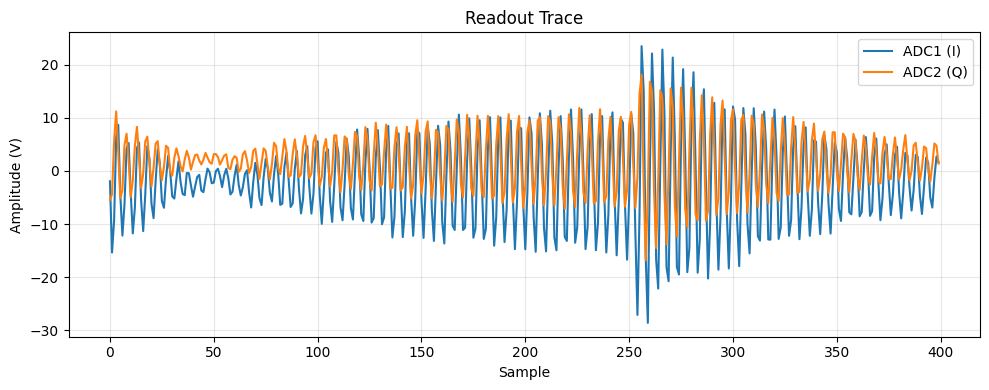

{'trace_length': 400}


In [4]:
trace = ReadoutTrace(session)
result = trace.run(attr.ro_fq, n_avg=100000, ro_therm_clks=1000)

analysis = trace.analyze(result)
trace.plot(analysis)
print(analysis.metrics)

### 3.2 Resonator Spectroscopy

Sweep readout frequency to locate resonator resonance.

2026-02-25 00:00:06,736 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:00:06,792 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 9999/10000 [00:18<00:00, 534.90it/s]

[INFO] 2026-02-25 00:00:25,537 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594086
No errors


[INFO] 2026-02-25 00:00:25,563 qubox.hardware.program_runner: Job halted successfully.


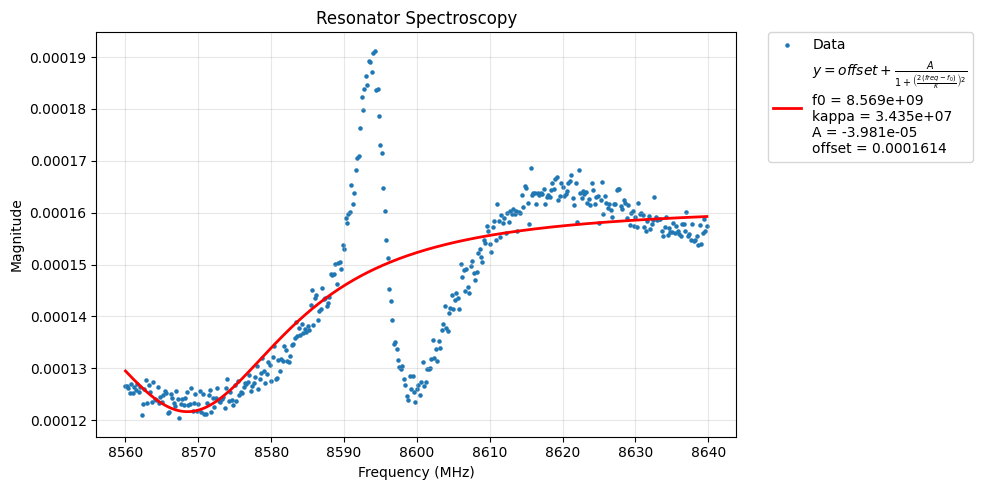

f0 = 8568.5113 MHz
kappa = 34346.6 kHz
Patch preview:
  {'op': 'SetCalibration', 'payload': {'path': 'frequencies.resonator.lo_freq', 'value': 8800000000.0}}
  {'op': 'SetCalibration', 'payload': {'path': 'frequencies.resonator.if_freq', 'value': -231488663.48150253}}


In [7]:
spec = ResonatorSpectroscopy(session)
res_cycle = orch.run_analysis_patch_cycle(
    spec,
    run_kwargs={
        "readout_op": "readout",
        "rf_begin": 8560 * u.MHz,
        "rf_end": 8640 * u.MHz,
        "df": 200 * u.kHz,
        "n_avg": 10000,
    },
    analyze_kwargs={"update_calibration": True},
    apply=False,
    persist_artifact=True,
)

res_result = orch._run_result_from_artifact(res_cycle["artifact"])
res_analysis = spec.analyze(res_result, update_calibration=False)
spec.plot(res_analysis)
print(f"f0 = {res_cycle['calibration_result'].params.get('f0_MHz', float('nan')):.4f} MHz")
print(f"kappa = {res_cycle['calibration_result'].params.get('kappa', float('nan')) / 1e3:.1f} kHz")
print("Patch preview:")
for item in res_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(res_cycle["patch"], dry_run=False)

### 3.3 Resonator Power Spectroscopy

2D sweep of readout frequency vs gain to find optimal readout power.

In [ ]:
pspec = ResonatorPowerSpectroscopy(session)
result = pspec.run(
    "readout",
    rf_begin=8590 * u.MHz,
    rf_end=8600 * u.MHz,
    df=50 * u.kHz,
    g_min=0.01,
    g_max=1.9,
    N_a=20,
    n_avg=5000,
)

analysis = pspec.analyze(result)
pspec.plot(analysis)
print(f"Optimal gain: {analysis.metrics.get('optimal_gain', 'N/A')}")
print(f"Optimal freq: {analysis.metrics.get('optimal_freq', 'N/A')}")

### 3.4 Resonator Spectroscopy with X180

Measure resonator with ground and excited qubit states to extract dispersive shift chi.

In [ ]:
spec_x180 = ResonatorSpectroscopyX180(session)
result = spec_x180.run(
    rf_begin=8560 * u.MHz,
    rf_end=8640 * u.MHz,
    df=200 * u.kHz,
    n_avg=10000,
)

analysis = spec_x180.analyze(result, update_calibration=True)
spec_x180.plot(analysis)
print(f"f0_g = {analysis.metrics.get('f0_g', 0) / 1e6:.4f} MHz")
print(f"f0_e = {analysis.metrics.get('f0_e', 0) / 1e6:.4f} MHz")
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")

## 4. Qubit Characterization

### 4.1 Qubit Spectroscopy

Sweep qubit drive frequency to locate the qubit transition.
Updates qubit frequency in the cooldown-scoped calibration store.

In [ ]:
qb_spec = QubitSpectroscopy(session)
qb_cycle = orch.run_analysis_patch_cycle(
    qb_spec,
    run_kwargs={
        "pulse": "saturation",
        "rf_begin": 6130 * u.MHz,
        "rf_end": 6170 * u.MHz,
        "df": 500 * u.kHz,
        "qb_gain": 1.0,
        "qb_len": 1000,
        "n_avg": 1000,
    },
    analyze_kwargs={"update_calibration": True},
    apply=False,
    persist_artifact=True,
)

qb_result = orch._run_result_from_artifact(qb_cycle["artifact"])
qb_analysis = qb_spec.analyze(qb_result, update_calibration=False)
qb_spec.plot(qb_analysis)
print(f"f0 = {qb_cycle['calibration_result'].params['f0_MHz']:.4f} MHz")
print("Patch preview:")
for item in qb_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(qb_cycle["patch"], dry_run=False)

### 4.2 Power Rabi

Sweep qubit drive amplitude to calibrate the pi pulse gain.
Updates `ref_r180` amplitude and derived primitives (cooldown-scoped).

Running Power Rabi on op='ref_r180' | pulse='ref_r180_pulse' | len=16 | peak=0.092626
2026-02-25 00:48:46,427 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:48:46,546 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 1999/2000 [00:12<00:00, 162.19it/s]

[INFO] 2026-02-25 00:48:58,880 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594158
No errors
[INFO] 2026-02-25 00:48:58,907 qubox.hardware.program_runner: Job halted successfully.


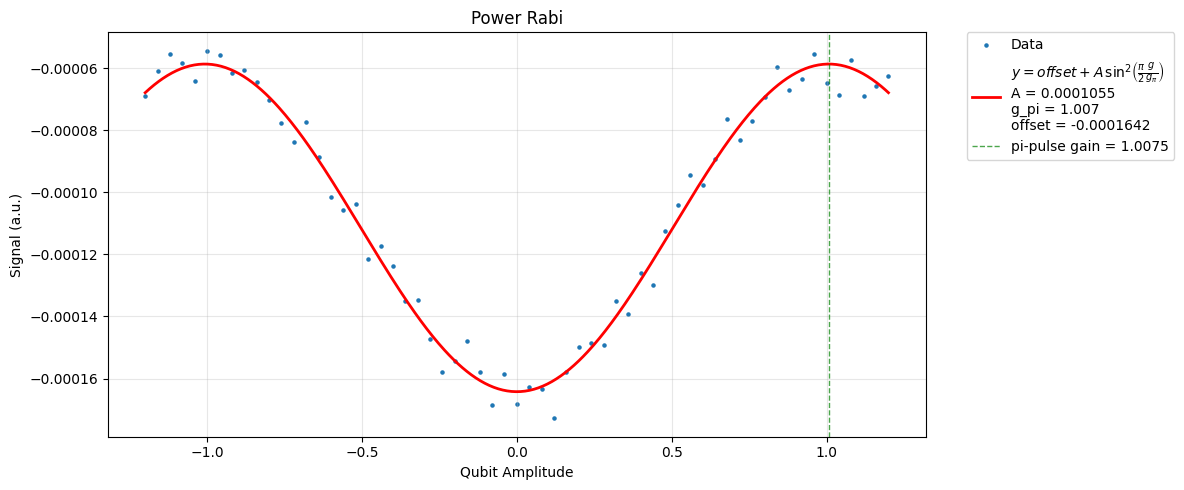

g_pi (ref_r180) = 1.007463
Patch preview:
  {'op': 'SetCalibration', 'payload': {'path': 'pulse_calibrations.ref_r180.amplitude', 'value': 0.09686021139618893}}
  {'op': 'SetPulseParam', 'payload': {'pulse_name': 'ref_r180', 'field': 'amplitude', 'value': 0.09686021139618893}}
  {'op': 'TriggerPulseRecompile', 'payload': {'include_volatile': True}}
  {'op': 'SetCalibration', 'payload': {'path': 'pulse_calibrations.ref_r180.amplitude', 'value': 0.09686021139618893}}
  {'op': 'TriggerPulseRecompile', 'payload': {'include_volatile': True}}


In [18]:
import importlib
import qubox_v2.calibration.orchestrator as orch_mod
importlib.reload(orch_mod)

orch = orch_mod.CalibrationOrchestrator(session)
rabi = PowerRabi(session)

POWER_RABI_OP = "ref_r180"

# Diagnostic: show the waveform currently used by Power Rabi
op_info = session.pulse_mgr.get_pulseOp_by_element_op(attr.qb_el, POWER_RABI_OP)
op_peak = max(float(np.max(np.abs(op_info.I_wf))), float(np.max(np.abs(op_info.Q_wf))))
print(f"Running Power Rabi on op='{POWER_RABI_OP}' | pulse='{op_info.pulse}' | len={op_info.length} | peak={op_peak:.6f}")

rabi_cycle = orch.run_analysis_patch_cycle(
    rabi,
    run_kwargs={
        "max_gain": 1.2,
        "dg": 0.04,
        "op": POWER_RABI_OP,
        "n_avg": 2000,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [0.0001, 1, 0],
    },
    apply=False,
    persist_artifact=True,
)

rabi_result = orch._run_result_from_artifact(rabi_cycle["artifact"])
rabi_analysis = rabi.analyze(rabi_result, update_calibration=False, p0=[0.0001, 1, 0])
rabi.plot(rabi_analysis)
rabi_g_pi = float(rabi_cycle["calibration_result"].params.get("g_pi", 1.0))
print(f"g_pi ({POWER_RABI_OP}) = {rabi_g_pi:.6f}")
print("Patch preview:")
for item in rabi_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(rabi_cycle["patch"], dry_run=False)

In [7]:
orch.apply_patch(rabi_cycle["patch"], dry_run=False)

[INFO] 2026-02-24 23:49:23,144 qubox.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-02-24 23:49:23,146 qubox.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-02-24 23:49:24,540 qubox.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-02-24 23:49:26,124 qubox.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-02-24 23:49:26,175 qubox.experiments.session: Saved pulse manager state to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json


{'dry_run': False,
 'n_updates': 5,
 'preview': [{'op': 'SetCalibration',
   'payload': {'path': 'pulse_calibrations.ref_r180.amplitude',
    'value': 0.09614269205403701}},
  {'op': 'SetPulseParam',
   'payload': {'pulse_name': 'ref_r180',
    'field': 'amplitude',
    'value': 0.09614269205403701}},
  {'op': 'TriggerPulseRecompile', 'payload': {'include_volatile': True}},
  {'op': 'SetCalibration',
   'payload': {'path': 'pulse_calibrations.ref_r180.amplitude',
    'value': 0.09614269205403701}},
  {'op': 'TriggerPulseRecompile', 'payload': {'include_volatile': True}}]}

### 4.3 Temporal Rabi

Sweep pulse duration at fixed amplitude to measure Rabi frequency.

In [ ]:
trabi = TemporalRabi(session)
result = trabi.run(
    pulse="const",
    pulse_len_begin=16,
    pulse_len_end=500,
    dt=4,
    n_avg=5000,
)

analysis = trabi.analyze(result)
trabi.plot(analysis)
print(f"f_Rabi = {analysis.metrics.get('f_Rabi', 'N/A')} Hz")
print(f"pi_length = {analysis.metrics.get('pi_length', 'N/A')} ns")

### 4.4 T1 Relaxation

Measure energy relaxation time after a pi pulse.
Stores T1 result in the cooldown-scoped calibration.

2026-02-25 00:50:03,284 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:50:03,370 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 1999/2000 [00:25<00:00, 79.62it/s]

[INFO] 2026-02-25 00:50:28,535 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594159
No errors


[INFO] 2026-02-25 00:50:28,561 qubox.hardware.program_runner: Job halted successfully.


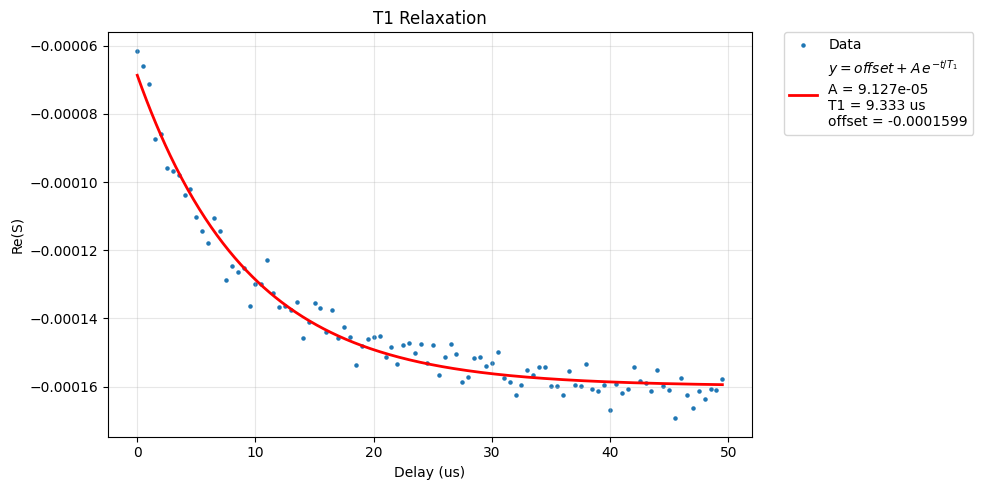

T1 = 9.33 us
qb_therm_clks (proposed) = 13998
Patch preview:
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T1', 'value': 9.33252720059438e-06}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T1_us', 'value': 9.33252720059438}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.qb_therm_clks', 'value': 13998}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T1', 'value': 9.33252720059438e-06}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T1_us', 'value': 9.33252720059438}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.qb_therm_clks', 'value': 13998}}


In [19]:
t1 = T1Relaxation(session)
t1_cycle = orch.run_analysis_patch_cycle(
    t1,
    run_kwargs={
        "delay_end": 50 * u.us,
        "dt": 500,
        "n_avg": 2000,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [0, 10, 0],
        "p0_time_unit": "us",
        "derive_qb_therm_clks": True,
        "clock_period_ns": 4.0,
    },
    apply=False,
    persist_artifact=True,
)

t1_result = orch._run_result_from_artifact(t1_cycle["artifact"])
t1_analysis = t1.analyze(t1_result, update_calibration=False, p0=[0, 10, 0], p0_time_unit="us")
t1.plot(t1_analysis)
print(f"T1 = {t1_cycle['calibration_result'].params.get('T1_us', float('nan')):.2f} us")
print(f"qb_therm_clks (proposed) = {t1_cycle['calibration_result'].params.get('qb_therm_clks', 'N/A')}")
print("Patch preview:")
for item in t1_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(t1_cycle["patch"], dry_run=False)

### 4.5 T2 Ramsey

Ramsey interferometry with intentional detuning to measure T2*.
Applies frequency correction if configured (cooldown-scoped).

2026-02-24 23:54:07,592 - qm - INFO     - Sending program to QOP for compilation
2026-02-24 23:54:07,658 - qm - INFO     - Executing program


Running Program...:  77%|███████▋  | 3066/4000 [02:27<00:45, 20.73it/s]

[INFO] 2026-02-24 23:56:35,634 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594084
No errors


[INFO] 2026-02-24 23:56:35,665 qubox.hardware.program_runner: Job halted successfully.


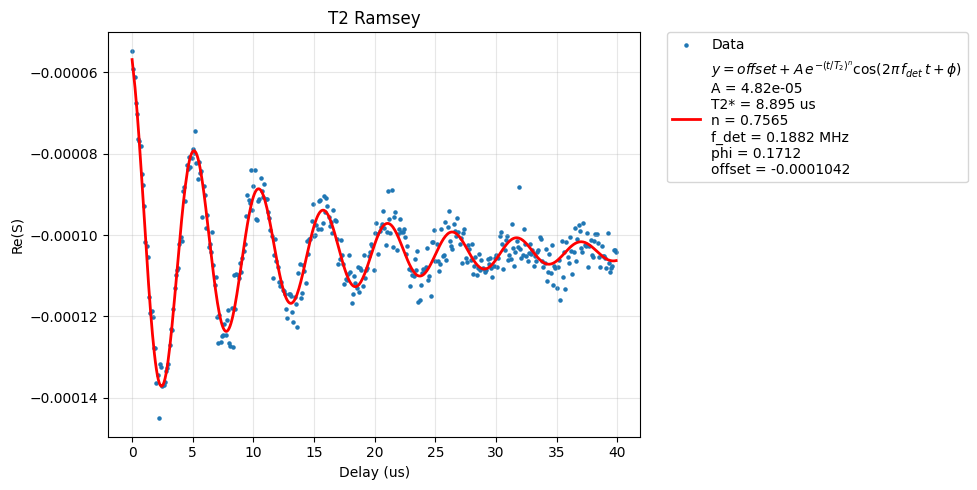

T2* = 8.90 us
f_det = 0.1882 MHz
Patch preview:
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T2_ramsey', 'value': 8895.145344397799}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T2_star_us', 'value': 8.895145344397799}}
  {'op': 'SetCalibration', 'payload': {'path': 'frequencies.qubit.qubit_freq', 'value': 6150369483.897038}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T2_ramsey', 'value': 8895.145344397799}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T2_star_us', 'value': 8.895145344397799}}
  {'op': 'SetCalibration', 'payload': {'path': 'frequencies.qubit.qubit_freq', 'value': 6150369483.897038}}


In [14]:
t2r = T2Ramsey(session)
qb_det_MHz = 0.2
t2r_cycle = orch.run_analysis_patch_cycle(
    t2r,
    run_kwargs={
        "qb_detune": int(qb_det_MHz * 1e6),
        "delay_end": 40 * u.us,
        "dt": 100,
        "n_avg": 4000,
        "qb_detune_MHz": qb_det_MHz,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [0, 20, 1.0, qb_det_MHz, 0.0, 0],
        "p0_time_unit": "us",
        "p0_freq_unit": "MHz",
        "apply_frequency_correction": True,
        "freq_correction_sign": -1.0,
    },
    apply=False,
    persist_artifact=True,
)

t2r_result = orch._run_result_from_artifact(t2r_cycle["artifact"])
t2r_analysis = t2r.analyze(
    t2r_result,
    update_calibration=False,
    p0=[0, 20, 1.0, qb_det_MHz, 0.0, 0],
    p0_time_unit="us",
    p0_freq_unit="MHz",
)
t2r.plot(t2r_analysis)
print(f"T2* = {t2r_cycle['calibration_result'].params.get('T2_star_us', float('nan')):.2f} us")
print(f"f_det = {t2r_cycle['calibration_result'].params.get('f_det_MHz', float('nan')):.4f} MHz")
print("Patch preview:")
for item in t2r_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(t2r_cycle["patch"], dry_run=False)

### 4.6 T2 Echo

Hahn echo measurement for T2_echo (removing low-frequency dephasing).

2026-02-25 00:52:17,184 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:52:17,254 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 1999/2000 [00:48<00:00, 41.42it/s]

[INFO] 2026-02-25 00:53:05,572 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594163
No errors


[INFO] 2026-02-25 00:53:05,601 qubox.hardware.program_runner: Job halted successfully.


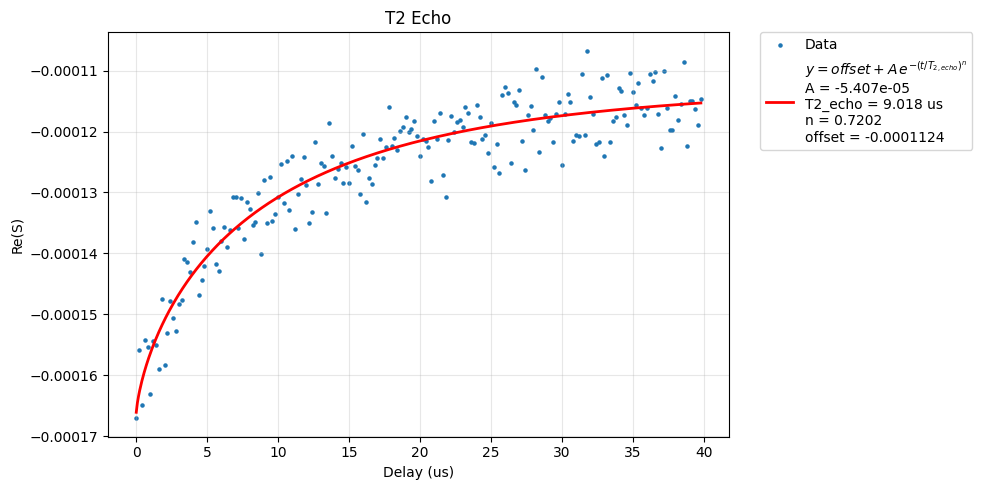

T2_echo = 9.02 us
Patch preview:
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T2_echo', 'value': 9018.459336101}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T2_echo_us', 'value': 9.018459336101}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T2_echo', 'value': 9018.459336101}}
  {'op': 'SetCalibration', 'payload': {'path': 'coherence.qubit.T2_echo_us', 'value': 9.018459336101}}


In [5]:
t2e = T2Echo(session)
t2e_cycle = orch.run_analysis_patch_cycle(
    t2e,
    run_kwargs={
        "delay_end": 40 * u.us,
        "dt": 200,
        "n_avg": 2000,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [-1, 40, 1.0, 0],
        "p0_time_unit": "us",
    },
    apply=False,
    persist_artifact=True,
)

t2e_result = orch._run_result_from_artifact(t2e_cycle["artifact"])
t2e_analysis = t2e.analyze(t2e_result, update_calibration=False, p0=[-1, 40, 1.0, 0], p0_time_unit="us")
t2e.plot(t2e_analysis)
print(f"T2_echo = {t2e_cycle['calibration_result'].params.get('T2_echo_us', float('nan')):.2f} us")
print("Patch preview:")
for item in t2e_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(t2e_cycle["patch"], dry_run=False)

### 4.7 Primitive Pulse Waveform Update

Apply the Power Rabi calibration (`g_pi`) to the reference pulse and regenerate
all qubit rotation waveforms.

In [8]:
# Commit PowerRabi patch after manual preview approval
print("PowerRabi patch preview:")
for item in rabi_cycle["dry_run"]["preview"]:
    print(" ", item)

# Show expected amplitude correction before patch apply
ref_name = "ref_r180"
pre_ref_cal = session.calibration.get_pulse_calibration(ref_name)
pre_amp_raw = getattr(pre_ref_cal, "amplitude", None) if pre_ref_cal is not None else None
pre_amp = float(pre_amp_raw) if pre_amp_raw is not None else float("nan")
print(f"\nCurrent ref_r180 calibration amplitude (before patch): {pre_amp:.6f}")
print(f"Latest fitted g_pi from Section 4.2:                  {rabi_g_pi:.6f}")
if np.isfinite(pre_amp):
    print(f"Expected corrected amplitude (~pre_amp * g_pi):       {pre_amp * rabi_g_pi:.6f}")
else:
    print("Expected corrected amplitude: unavailable (missing pre-patch amplitude)")

# Commit the previewed patch
rabi_apply = orch.apply_patch(rabi_cycle["patch"], dry_run=False)
print("\nPatch apply result:", rabi_apply)

# Rebuild ref_r180 + primitive waveforms from UPDATED calibration values
from qubox_v2.tools.waveforms import drag_gaussian_pulse_waveforms
from qubox_v2.tools.generators import register_rotations_from_ref_iq

ref_cal = session.calibration.get_pulse_calibration(ref_name)
amp_after_patch_raw = getattr(ref_cal, "amplitude", None) if ref_cal is not None else None

if amp_after_patch_raw is not None:
    ref_amp = float(amp_after_patch_raw)
    amp_source = "calibration_store"
elif np.isfinite(pre_amp):
    # Safe fallback: reconstruct voltage amplitude from prior amplitude * fitted gain factor
    ref_amp = float(pre_amp * rabi_g_pi)
    session.calibration.set_pulse_calibration(name=ref_name, amplitude=ref_amp)
    amp_source = "reconstructed_pre_amp_times_g_pi"
    print("[warn] ref_r180 amplitude missing after patch; reconstructed from pre_amp * g_pi and wrote back to calibration.")
else:
    raise RuntimeError(
        "ref_r180 amplitude is missing after patch and pre-patch amplitude is unavailable; "
        "cannot convert g_pi factor into physical voltage amplitude."
    )

ref_len = int(getattr(ref_cal, "length", getattr(attr, "rlen", 16)))
ref_sigma = getattr(ref_cal, "sigma", None)
if ref_sigma is None:
    ref_sigma = ref_len / 6.0
ref_sigma = float(ref_sigma)
ref_drag = float(getattr(ref_cal, "drag_coeff", 0.0) or 0.0)
anh = float(getattr(attr, "anharmonicity", 0) or -200e6)

ref_I, ref_Q = drag_gaussian_pulse_waveforms(
    amplitude=ref_amp,
    length=ref_len,
    sigma=ref_sigma,
    alpha=ref_drag,
    anharmonicity=anh,
    subtracted=True,
)

pm = session.pulse_mgr
updated_ops = register_rotations_from_ref_iq(
    pm,
    ref_I=ref_I,
    ref_Q=ref_Q,
    element=attr.qb_el,
    rotations="all",
    make_r0=False,
    override=True,
    persist=True,
)

session.burn_pulses()
session.save_pulses()

# Verify runtime pulse manager sees updated waveforms
ref_info = pm.get_pulseOp_by_element_op(attr.qb_el, "ref_r180")
ref_peak = max(float(np.max(np.abs(ref_info.I_wf))), float(np.max(np.abs(ref_info.Q_wf))))

scale = ref_amp / pre_amp if np.isfinite(pre_amp) and pre_amp != 0 else float("nan")
print("\nRebuilt ops:", list(updated_ops.keys()))
print(f"Amplitude source used:                  {amp_source}")
print(f"Updated ref_r180 calibration amplitude: {ref_amp:.6f}")
print(f"Amplitude scale factor (after/before):   {scale:.6f}")
print(f"Updated ref_r180 waveform peak:          {ref_peak:.6f}")
print("Now rerun Section 4.2 (Power Rabi); expected fitted g_pi should be near 1.")

if np.isfinite(pre_amp) and np.isfinite(ref_amp) and np.isfinite(rabi_g_pi):
    if (rabi_g_pi < 1.0 and ref_amp > pre_amp) or (rabi_g_pi > 1.0 and ref_amp < pre_amp):
        print("[warn] Applied amplitude direction is opposite to g_pi expectation. Rerun Section 4.2 after reloading latest code before applying patch.")

PowerRabi patch preview:
  {'op': 'SetCalibration', 'payload': {'path': 'pulse_calibrations.ref_r180.amplitude', 'value': 0.09614269205403701}}
  {'op': 'SetPulseParam', 'payload': {'pulse_name': 'ref_r180', 'field': 'amplitude', 'value': 0.09614269205403701}}
  {'op': 'TriggerPulseRecompile', 'payload': {'include_volatile': True}}
  {'op': 'SetCalibration', 'payload': {'path': 'pulse_calibrations.ref_r180.amplitude', 'value': 0.09614269205403701}}
  {'op': 'TriggerPulseRecompile', 'payload': {'include_volatile': True}}

Current ref_r180 calibration amplitude (before patch): 0.096143
Latest fitted g_pi from Section 4.2:                  1.055844
Expected corrected amplitude (~pre_amp * g_pi):       0.101512
[INFO] 2026-02-24 23:49:26,193 qubox.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-02-24 23:49:26,194 qubox.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\coold

## 5. Pulse Calibration

### 5.1 DRAG Calibration

Sweep DRAG coefficient to minimize leakage to the second excited state.
Stores DRAG alpha in the cooldown-scoped calibration.

In [ ]:
drag = DRAGCalibration(session)
drag_cycle = orch.run_analysis_patch_cycle(
    drag,
    run_kwargs={
        "amps": np.linspace(-0.5, 0.5, 20),
        "n_avg": 5000,
        "base_alpha": 1.0,
    },
    analyze_kwargs={
        "update_calibration": True,
    },
    apply=False,
    persist_artifact=True,
)

drag_result = orch._run_result_from_artifact(drag_cycle["artifact"])
drag_analysis = drag.analyze(drag_result, update_calibration=False)
drag.plot(drag_analysis)
print(f"Optimal alpha = {drag_cycle['calibration_result'].params.get('optimal_alpha', 'N/A')}")
print("Patch preview:")
for item in drag_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after quality review:
# orch.apply_patch(drag_cycle["patch"], dry_run=False)

### 5.1b DRAG Calibration Commit

Wrap the DRAG calibration result in a `CalibrationStateMachine` lifecycle
and commit via `CalibrationPatch` if the fit quality passes validation.

In [ ]:
from qubox_v2.calibration.state_machine import (
    CalibrationStateMachine, CalibrationState,
    CalibrationPatch, PatchValidation,
)

sm_drag = CalibrationStateMachine(experiment="drag_calibration")
sm_drag.transition(CalibrationState.CONFIGURED)
sm_drag.transition(CalibrationState.ACQUIRING)
sm_drag.transition(CalibrationState.ACQUIRED)
sm_drag.transition(CalibrationState.ANALYZING)

optimal_alpha = drag_analysis.metrics.get("optimal_alpha", None)

drag_cal = session.calibration.get_pulse_calibration("ref_r180")
old_drag = drag_cal.drag_coeff if (drag_cal and drag_cal.drag_coeff is not None) else 0.0

drag_patch = CalibrationPatch(experiment="drag_calibration")
drag_patch.add_change(
    path="pulse_calibrations.ref_r180.drag_coeff",
    old_value=float(old_drag),
    new_value=float(optimal_alpha) if optimal_alpha is not None else None,
)

alpha_valid = optimal_alpha is not None and np.isfinite(optimal_alpha)
bounds_ok = alpha_valid and abs(optimal_alpha) < 5.0

drag_patch.validation = PatchValidation(
    passed=alpha_valid and bounds_ok,
    checks={"alpha_finite": alpha_valid, "alpha_bounds": bounds_ok},
    reasons=[] if (alpha_valid and bounds_ok) else
            [f"optimal_alpha={optimal_alpha} out of range or invalid"],
)
drag_patch.metadata = {"optimal_alpha": optimal_alpha}
sm_drag.patch = drag_patch

sm_drag.transition(CalibrationState.ANALYZED)
sm_drag.transition(CalibrationState.PENDING_APPROVAL)

print(drag_patch.summary())

if drag_patch.is_approved():
    sm_drag.transition(CalibrationState.COMMITTING)
    sm_drag.transition(CalibrationState.COMMITTED)
    print(f"\nDRAG commit recorded: alpha = {optimal_alpha:.4f}")
    am.save_artifact("drag_calibration_patch", drag_patch.to_dict())
else:
    am.save_artifact("drag_calibration_candidate", drag_patch.to_dict())
    print("\nDRAG calibration NOT committed. Candidate saved as artifact.")

### 5.1c Pulse-Train Rotation Calibration (Tomography)

Full 3-axis qubit state tomography at each N with multiple preps.
Fits Bloch-vector evolution via DE+LS global optimisation to extract
amplitude error, phase error, detuning, and zeta (per-step Z rotation).
Converts to QubitRotation knob corrections (d_lambda, d_alpha, d_omega).

Uses the unified `run() -> analyze() -> plot()` protocol via `PulseTrainCalibration(session)`.

In [ ]:
from qm.qua import play, align
from qubox_v2.experiments.gates_legacy import QubitRotation

pt = PulseTrainCalibration(session)

theta = np.pi
phi = 0.0
N_values = np.arange(0, 80, 8)
n_avg = 20000

# Prep using primitives (x90/y90/xn90/yn90/x180)
def prep_e():  play("x180", attr.qb_el)
def prep_px(): play("y90", attr.qb_el)
def prep_mx(): play("yn90", attr.qb_el)
def prep_py(): play("xn90", attr.qb_el)
def prep_my(): play("x90", attr.qb_el)

prep_defs = {
    "g": None, "e": prep_e,
    "+x": prep_px, "+y": prep_py, "-x": prep_mx, "-y": prep_my,
}

# Gate under test
arb_rot = QubitRotation(theta, phi, ref_r180_pulse="ref_r180_pulse", build=True)
session.burn_pulses()

# Run tomography sweep
result = pt.run(
    arb_rot=arb_rot, prep_defs=prep_defs, N_values=N_values,
    n_avg=n_avg, theta=theta, phi=phi, verbose=True, sanity_check=True,
)

# Analyse â€” knob conversion requires dt_s and n_samp
_Iw, _Qw, waveform_len, marker = arb_rot.waveforms()
dt_s = float(getattr(attr, "dt_s", 1e-9))
n_samp = int(waveform_len)

analysis = pt.analyze(
    result, fit_zeta=True, multi_seed=True, seeds=range(1, 2),
    seed_select="ls", verbose=True,
    dt_s=dt_s, n_samp=n_samp, d_omega_sign=1.0,
    bounds={"delta": (-0.001, 0.001), "amp_err": (-0.05, +0.05),
            "phase_err": (-0.2, +0.2), "zeta": (-0.1, 0.1)},
)

# Plot
pt.plot(analysis, residual_mode="both")

# Print fit results and knob corrections
print(f"amp_err    = {analysis.metrics['amp_err']:+.4%}")
print(f"phase_err  = {analysis.metrics['phase_err']:+.6f} rad")
print(f"delta      = {analysis.metrics['delta']:+.6f} rad/pulse")
print(f"zeta       = {analysis.metrics['zeta']:+.6f} rad/step")
if "d_lambda" in analysis.metrics:
    print(f"d_lambda   = {analysis.metrics['d_lambda']:+.6e}")
    print(f"d_alpha    = {analysis.metrics['d_alpha']:+.6f} rad")
    print(f"d_omega    = {analysis.metrics['d_omega']:+.6e} rad/s")

### 5.1d Verify Run (Apply Knob Corrections)

Re-run pulse-train tomography with the fitted knob corrections applied to
the `QubitRotation` gate. Uses a 3-prep subset (g, +x, +y) at half `n_avg`
for faster verification.

**NEEDS_RUN**: Requires QOP connection.

In [ ]:
# Apply knob corrections from the initial fit and re-run tomography
APPLY_KNOBS = True

theta_v = theta
phi_v = phi

kwargs_knobs = {}
if APPLY_KNOBS and "d_lambda" in analysis.metrics:
    kwargs_knobs = dict(
        d_lambda=analysis.metrics["d_lambda"],
        d_alpha=analysis.metrics["d_alpha"],
        d_omega=analysis.metrics["d_omega"],
    )
    print(f"Applying knobs: d_lambda={kwargs_knobs['d_lambda']:+.6e}, "
          f"d_alpha={kwargs_knobs['d_alpha']:+.6f}, "
          f"d_omega={kwargs_knobs['d_omega']:+.6e}")

arb_rot_corrected = QubitRotation(
    theta_v, phi_v,
    ref_r180_pulse="ref_r180_pulse",
    build=True,
    **kwargs_knobs,
)
session.burn_pulses()

# Subset preps for verification
prep_defs_verify = {
    "g": None,
    "+x": prep_px,
    "+y": prep_py,
}

N_values_v = N_values
n_avg_v = n_avg // 2

result_v = pt.run(
    arb_rot=arb_rot_corrected, prep_defs=prep_defs_verify,
    N_values=N_values_v, n_avg=n_avg_v,
    theta=theta_v, phi=phi_v, verbose=True, sanity_check=True,
)
print("Verify run complete.")

### 5.1e Verify Analysis (Before vs After)

Compare angular deviation from ideal Bloch trajectories before and after
correction. No fitting is performed on verify data â€” purely a comparison
against zero-error expectations.

In [ ]:
# Analyse the verify run â€” compare before and after angular errors
analysis_v = pt.analyze(
    result_v, fit_zeta=False, verbose=False,
    dt_s=dt_s, n_samp=n_samp,
)

pt.plot(analysis_v, residual_mode="both")

# Angular comparison (if available in metrics)
print("\nVerify run metrics:")
for k in ["amp_err", "phase_err", "delta", "zeta"]:
    before = analysis.metrics.get(k, float("nan"))
    after = analysis_v.metrics.get(k, float("nan"))
    print(f"  {k:12s}  before={before:+.6f}  after={after:+.6f}")

print("\nKnobs applied:", kwargs_knobs)

### 5.1f Apply Corrections to All Standard Rotations

Broadcast the calibrated knob corrections to all pi/2 and pi rotation gates
(x90, y90, xn90, yn90, x180, y180) by rebuilding from the DRAG Gaussian
reference pulse with per-gate knob maps.

**NEEDS_RUN**: Requires `register_rotations_from_ref_iq` and pulse persistence.

In [ ]:
from qubox_v2.tools.waveforms import drag_gaussian_pulse_waveforms
from qubox_v2.tools.generators import register_rotations_from_ref_iq

# Knob values from the fit (edit after calibration)
d_lambda_90  = analysis.metrics.get("d_lambda", 0.0)
d_alpha_90   = analysis.metrics.get("d_alpha", 0.0)
d_omega_90   = 0.0

d_lambda_180 = d_lambda_90  # scale if needed
d_alpha_180  = d_alpha_90
d_omega_180  = 0.0

PI2_ROTS = ["x90", "y90", "xn90", "yn90"]
PI_ROTS  = ["x180", "y180"]

d_lambda_map = {k: float(d_lambda_90) for k in PI2_ROTS}
d_alpha_map  = {k: float(d_alpha_90)  for k in PI2_ROTS}
d_omega_map  = {k: float(d_omega_90)  for k in PI2_ROTS}
d_lambda_map.update({k: float(d_lambda_180) for k in PI_ROTS})
d_alpha_map.update({k: float(d_alpha_180)  for k in PI_ROTS})
d_omega_map.update({k: float(d_omega_180)  for k in PI_ROTS})

# Rebuild reference DRAG Gaussian pulse
pcal_ref = session.calibration.get_pulse_calibration("ref_r180")
ref_amp = getattr(pcal_ref, "amplitude", rabi_g_pi)
ref_len = getattr(pcal_ref, "length", 40)
ref_drag = getattr(pcal_ref, "drag_coeff", 0.0)
anh = float(getattr(attr, "anharmonicity", 0) or -200e6)

gauss_r180, drag_r180 = drag_gaussian_pulse_waveforms(
    amplitude=ref_amp, length=ref_len,
    alpha=ref_drag, anharmonicity=anh, subtracted=True,
)

pm = session.pulse_mgr
res = register_rotations_from_ref_iq(
    pm,
    ref_I=gauss_r180,
    ref_Q=drag_r180,
    element=attr.qb_el,
    rotations="all",
    make_r0=True,
    override=True,
    persist=True,
    d_lambda_map=d_lambda_map,
    d_alpha_map=d_alpha_map,
    d_omega_map=d_omega_map,
)
session.burn_pulses()
session.save_pulses()

print("Broadcast rotation knobs to all standard gates:")
for gate_name, (I, Q) in res.items():
    print(f"  {gate_name:6s}: len={len(I)}, max_I={max(abs(I)):.6f}, "
          f"d_lambda={d_lambda_map.get(gate_name, 0):.1f}, "
          f"d_alpha={d_alpha_map.get(gate_name, 0):.6f}")
print("\nPulses saved to disk.")

### 5.2 AllXY

21-point gate error diagnostic. Ideal result is the stepped staircase pattern.

2026-02-25 00:53:27,571 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:53:28,382 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:10<00:00, 469.22it/s]

[INFO] 2026-02-25 00:53:39,045 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594164
No errors
[INFO] 2026-02-25 00:53:39,080 qubox.hardware.program_runner: Job halted successfully.


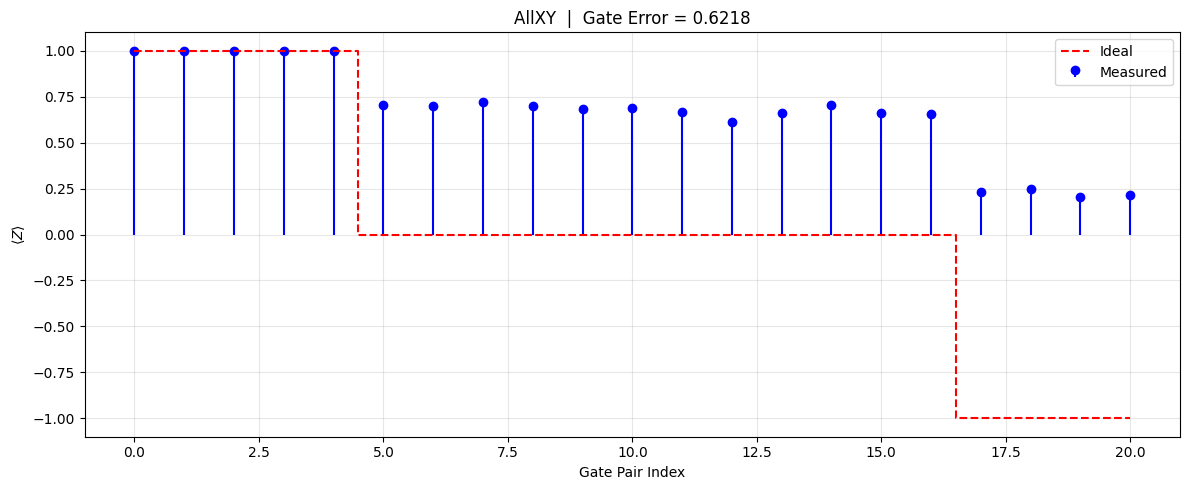

Gate error = 0.6218
Observable = sigma_z
State map  = {'g': 1.0, 'e': -1.0}
Confusion correction used = True
Confusion matrix present  = True


In [6]:
from qubox_v2.programs.macros.measure import measureMacro

allxy = AllXY(session)
result = allxy.run(n_avg=5000)
analysis = allxy.analyze(result)
allxy.plot(analysis)

print(f"Gate error = {analysis.metrics.get('gate_error', float('nan')):.4f}")
print(f"Observable = {analysis.metrics.get('observable', 'unknown')}")
print(f"State map  = {analysis.metrics.get('state_mapping', {})}")
print(f"Confusion correction used = {analysis.metrics.get('used_confusion_correction', False)}")
print(f"Confusion matrix present  = {measureMacro._ro_quality_params.get('confusion_matrix') is not None}")

In [ ]:
from qubox_v2.programs.macros.measure import measureMacro
confusion = measureMacro._ro_quality_params.get("confusion_matrix", None)
confusion

### 5.3 Randomized Benchmarking

Single-qubit Clifford RB for average gate fidelity.

In [ ]:
rb = RandomizedBenchmarking(session)
result = rb.run(
    m_list=[1, 5, 10, 20, 50, 100, 200],
    num_sequence=20,
    n_avg=1000,
)

analysis = rb.analyze(result, p0=[0.99, 0.5, 0.5])
rb.plot(analysis)
print(f"p = {analysis.metrics.get('p', 'N/A')}")
print(f"Avg gate fidelity = {analysis.metrics.get('avg_gate_fidelity', 'N/A')}")
print(f"Error per gate = {analysis.metrics.get('error_per_gate', 'N/A')}")

## 6. Readout Calibration

### 6.1 IQ Blob

Acquire IQ blobs for ground and excited states.

2026-02-25 00:06:37,136 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:06:37,198 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:01<00:00, 4378.86it/s]

[INFO] 2026-02-25 00:06:38,399 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594094
No errors


[INFO] 2026-02-25 00:06:38,461 qubox.hardware.program_runner: Job halted successfully.


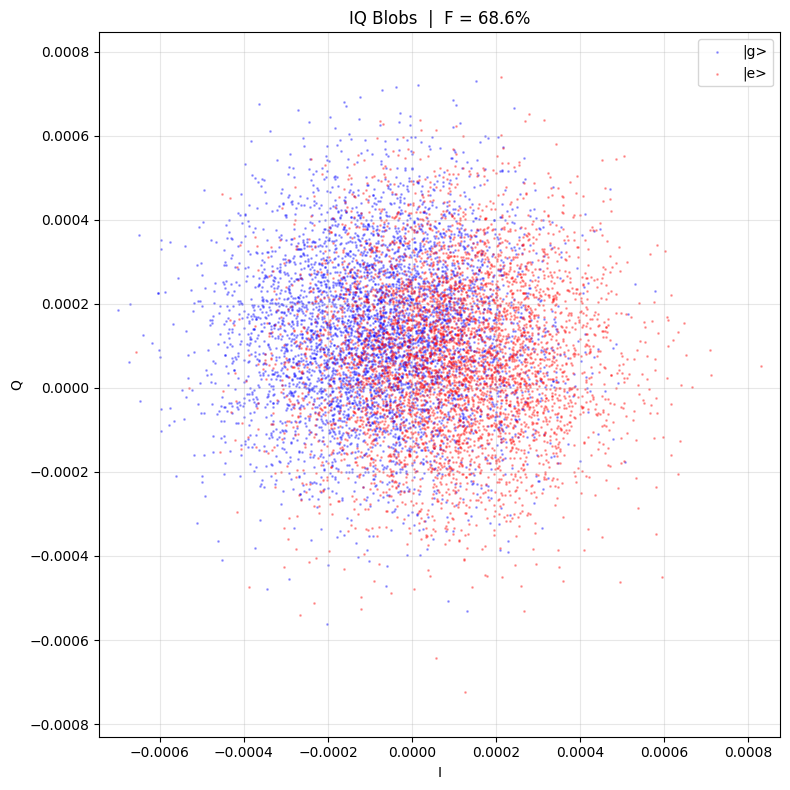

Readout fidelity = 68.58% (raw=68.58)


In [13]:
iq = IQBlob(session)
result = iq.run("x180", n_runs=5000)

analysis = iq.analyze(result)
iq.plot(analysis)

raw_fidelity = float(analysis.metrics.get("fidelity", float("nan")))
fidelity_frac = raw_fidelity / 100.0 if np.isfinite(raw_fidelity) and raw_fidelity > 1.0 else raw_fidelity
print(f"Readout fidelity = {fidelity_frac:.2%} (raw={raw_fidelity:.4g})")

### 6.2 Readout Weight Optimization

Optimize integration weights using time-sliced g/e readout traces.

In [ ]:
wopt = ReadoutWeightsOptimization(session)
result = wopt.run(
    ro_op="readout",
    drive_frequency=attr.ro_fq,
    cos_w_key="cos",
    sin_w_key="sin",
    m_sin_w_key="minus_sin",
    num_div=1,
    r180="x180",
    n_avg=200_000,
    persist=True,
    set_measure_macro=True,
)

analysis = wopt.analyze(result)
wopt.plot(analysis)

print(f"trace_length     = {analysis.metrics.get('trace_length', 'N/A')}")
print(f"ge_diff_norm_max = {analysis.metrics.get('ge_diff_norm_max', 'N/A'):.4f}")
print(f"opt_cos_key      = {analysis.metrics.get('opt_cos_key', 'N/A')}")
print(f"opt_sin_key      = {analysis.metrics.get('opt_sin_key', 'N/A')}")
print(f"opt_m_sin_key    = {analysis.metrics.get('opt_m_sin_key', 'N/A')}")

### 6.3 GE Discrimination

Full discrimination analysis â€” rotation angle, threshold, confusion matrix.
Stores weights/threshold/confusion in the cooldown-scoped calibration.

**Invariant contract for GE -> Butterfly consistency:**
- Same readout element/operation pulse mapping is used in both steps.
- Same active integration-weight set (prefer rotated triplet) is used in both steps.
- Same IQ rotation convention (`S_rot = S * exp(+1j*angle)`) and same threshold are used.
- Fidelity definitions are tracked explicitly:
  - GE: assignment fidelity (balanced accuracy, percent).
  - Butterfly `F`: assignment fidelity on M1 (balanced accuracy, fraction).
- Any GE/BF state mismatch is surfaced via readout-state hash and warnings.

[INFO] 2026-02-25 00:55:24,456 qubox.experiments.calibration.readout: GE discrimination: n_samples=50000, measure_op='readout'
[INFO] 2026-02-25 00:55:24,493 qubox.experiments.calibration.readout: GE discrimination mapping: element=resonator op=readout pulse=readout_pulse available_ops=['const', 'readout']
2026-02-25 00:55:24,599 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:55:24,666 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:10<00:00, 4918.96it/s]

[INFO] 2026-02-25 00:55:34,892 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594167
No errors
[INFO] 2026-02-25 00:55:34,966 qubox.hardware.program_runner: Job halted successfully.


[INFO] 2026-02-25 00:55:36,895 qubox.experiments.calibration.readout: GE discrimination fidelity=70.08%, angle=0.2857 rad, threshold=-2.116e-05
[INFO] 2026-02-25 00:55:36,896 qubox.experiments.calibration.readout: Strict mode: rotated weight/macro updates emitted as patch intent
[INFO] 2026-02-25 00:55:36,896 qubox.experiments.calibration.readout: GE discrimination state pushed to measureMacro: hash=9092988a2edaa2f8 thr=-2.11557e-05 angle=0.285701
[INFO] 2026-02-25 00:55:36,897 qubox.experiments.calibration.readout: Strict mode: runtime post-selection config refreshed from GE discrimination
[INFO] 2026-02-25 00:55:36,898 qubox.experiments.experiment_base: Inline calibration mutation suppressed for readout_ge_discrimination (strict mode). Artifact written at E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\artifacts\calibration_runs\readout_ge_discrimination_20260225_005536.json; orchestrator patch application required.


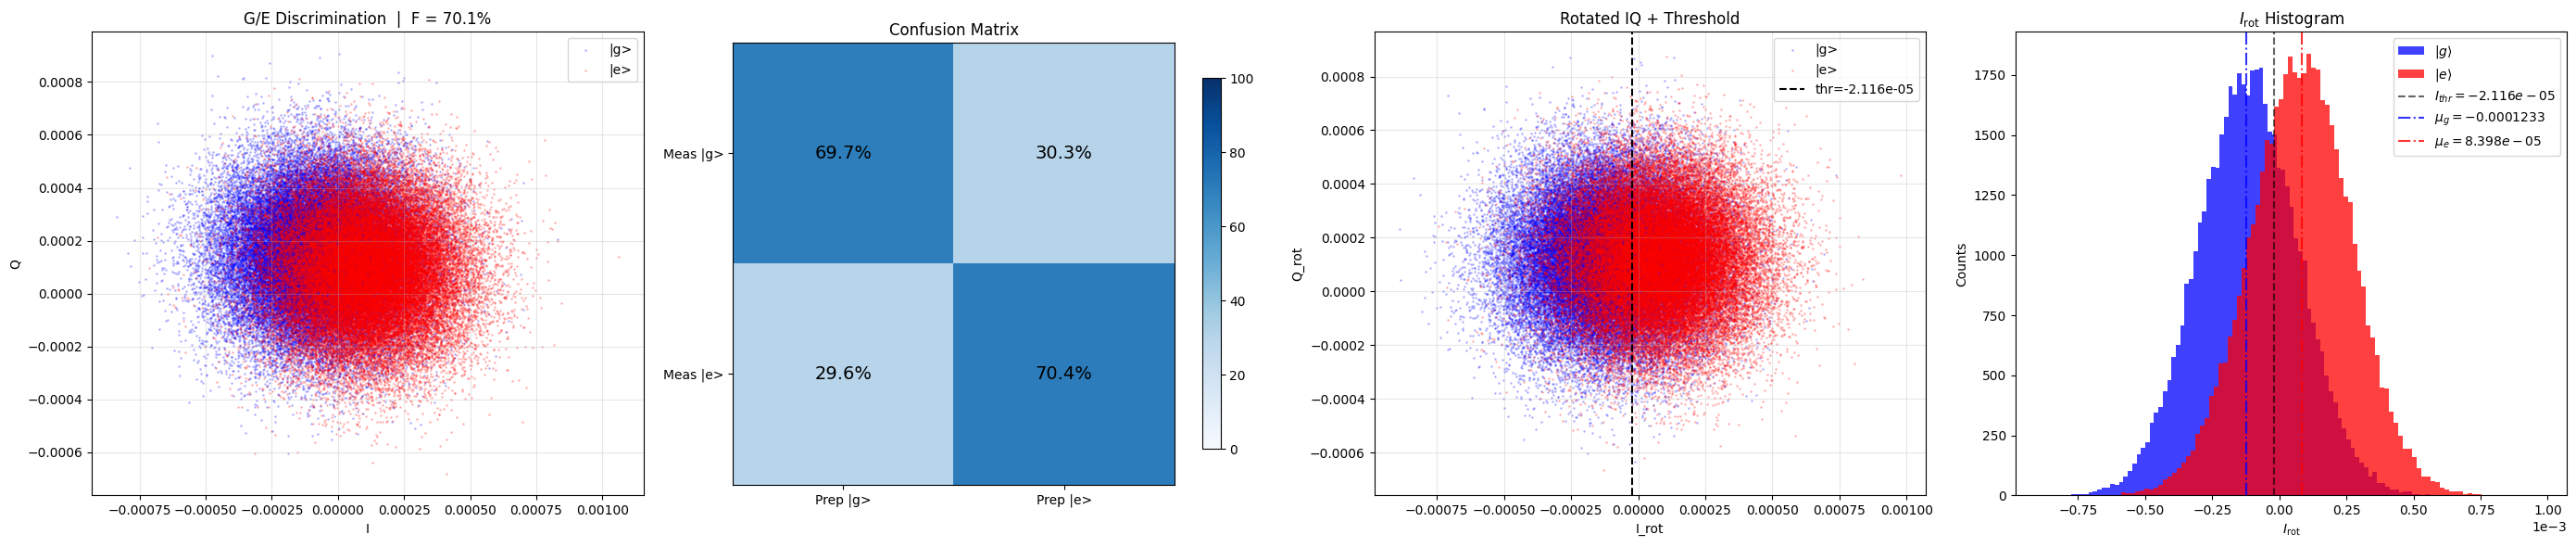

Fidelity = 70.08%
Angle = 0.286 rad
Threshold = -0.0000
Fidelity definition = assignment_fidelity_balanced_accuracy_percent

Resolved readout_ge mapping:
  element_readout: resonator
  operation:       readout
  pulse key:       readout_pulse
  base weights:    cos=readout_cosine_weights, sin=readout_sine_weights, m_sin=readout_minus_weights

GE readout-state signature:
  hash:      9092988a2edaa2f8
  element:   resonator
  operation: readout
  pulse:     readout_pulse
  weights:   {'cos': 'rot_cos', 'sin': 'rot_sin', 'minus_sin': 'rot_m_sin'}
  angle:     0.28570117213271123
  threshold: -2.115568337313927e-05
Gaussianity (g) = 0.080
Gaussianity (e) = 0.178


In [9]:
import importlib
import qubox_v2.experiments.calibration.readout as readout_mod
importlib.reload(readout_mod)

from qubox_v2.experiments.calibration.readout import ReadoutGEDiscrimination
from qubox_v2.programs.macros.measure import measureMacro

ge = ReadoutGEDiscrimination(session)
result = ge.run(
    "readout",
    attr.ro_fq,
    r180="x180",
    n_samples=50000,
    update_measure_macro=True,
    apply_rotated_weights=True,
    persist=True,
)

analysis = ge.analyze(result, update_calibration=True)
ge.plot(analysis, show_rotated=True, interactive=False)
print(f"Fidelity = {analysis.metrics.get('fidelity', 0):.2f}%")
print(f"Angle = {analysis.metrics.get('angle', 0):.3f} rad")
print(f"Threshold = {analysis.metrics.get('threshold', 0):.4f}")
print(f"Fidelity definition = {analysis.metrics.get('fidelity_definition', 'N/A')}")

rp = getattr(ge, "_run_params", {})
print("\nResolved readout_ge mapping:")
print(f"  element_readout: {attr.ro_el}")
print(f"  operation:       {rp.get('measure_op')}")
print(f"  pulse key:       {getattr(rp.get('pulse_info', None), 'pulse', None)}")
print(f"  base weights:    cos={rp.get('base_cos_name')}, sin={rp.get('base_sin_name')}, m_sin={rp.get('base_m_sin_name')}")

disc_state = getattr(measureMacro, "_ro_disc_params", {}).get("qbx_readout_state", None)
if isinstance(disc_state, dict):
    print("\nGE readout-state signature:")
    print(f"  hash:      {disc_state.get('hash')}")
    print(f"  element:   {disc_state.get('element')}")
    print(f"  operation: {disc_state.get('operation')}")
    print(f"  pulse:     {disc_state.get('pulse')}")
    print(f"  weights:   {disc_state.get('weights')}")
    print(f"  angle:     {disc_state.get('angle')}")
    print(f"  threshold: {disc_state.get('threshold')}")
else:
    print("\n[warn] GE readout-state signature missing on measureMacro.")

if "gaussianity_g" in analysis.metrics:
    print(f"Gaussianity (g) = {analysis.metrics['gaussianity_g']:.3f}")
    print(f"Gaussianity (e) = {analysis.metrics['gaussianity_e']:.3f}")
if "cv_fidelity" in analysis.metrics:
    print(f"Cross-validated fidelity = {analysis.metrics['cv_fidelity']:.2%}")

### 6.4 Butterfly Measurement

Two successive measurements to quantify QND fidelity, F, Q, and V.

[INFO] 2026-02-25 00:55:39,725 qubox.experiments.calibration.readout: Butterfly measureMacro sync applied: element=resonator op=readout weights=['rot_cos', 'rot_sin', 'rot_m_sin']
[WARNING] 2026-02-25 00:55:39,726 qubox.experiments.calibration.readout: Butterfly readout state mismatch: GE hash=9092988a2edaa2f8, butterfly hash=cf6cfa775419164a
[WARNING] 2026-02-25 00:55:39,726 qubox.experiments.calibration.readout: Skipping stored post-select config: GE state signature unavailable or mismatched (state_reason=hash_mismatch)
[INFO] 2026-02-25 00:55:39,726 qubox.experiments.calibration.readout: Butterfly measurement: n_samples=50000, policy='BLOBS', source=fallback_blob_from_ge
2026-02-25 00:55:39,911 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:55:40,378 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:14<00:00, 3412.28it/s]

[INFO] 2026-02-25 00:55:55,134 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594168
No errors


[INFO] 2026-02-25 00:55:55,462 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-25 00:55:55,468 qubox.experiments.calibration.readout: Butterfly metrics: F=0.5727, Q=0.9597, V=0.1455, t01=0.0000, t10=0.0806
[WARNING] 2026-02-25 00:55:55,469 qubox.experiments.calibration.readout: GE-vs-Butterfly fidelity mismatch: GE=0.7008, F=0.5727, delta=12.81%
[INFO] 2026-02-25 00:55:55,472 qubox.experiments.experiment_base: Inline calibration mutation suppressed for readout_butterfly (strict mode). Artifact written at E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\artifacts\calibration_runs\readout_butterfly_20260225_005555.json; orchestrator patch application required.
[INFO] 2026-02-25 00:55:55,473 qubox.experiments.calibration.readout: Butterfly readout-quality updates emitted as patch ops
[INFO] 2026-02-25 00:55:55,473 qubox.experiments.calibration.readout: T1 decay correction: readout=400 ns, T1=7.5 us, factor=0.9482
F = 57.27%
Q = 95.97%
V = 0.1455
F defin

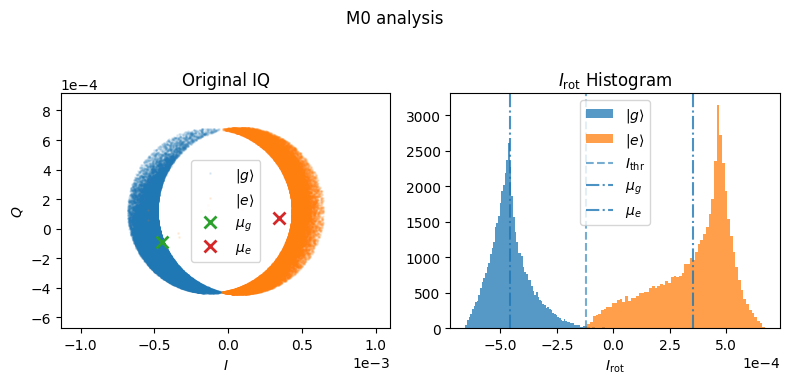

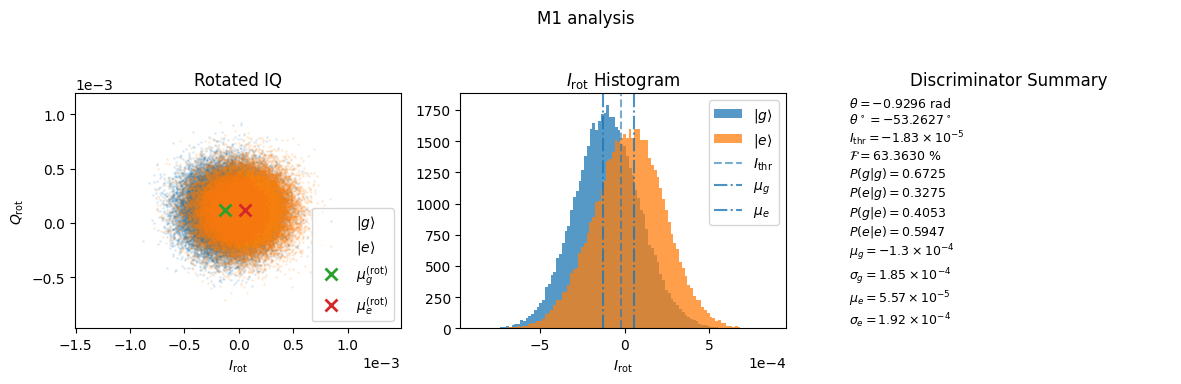

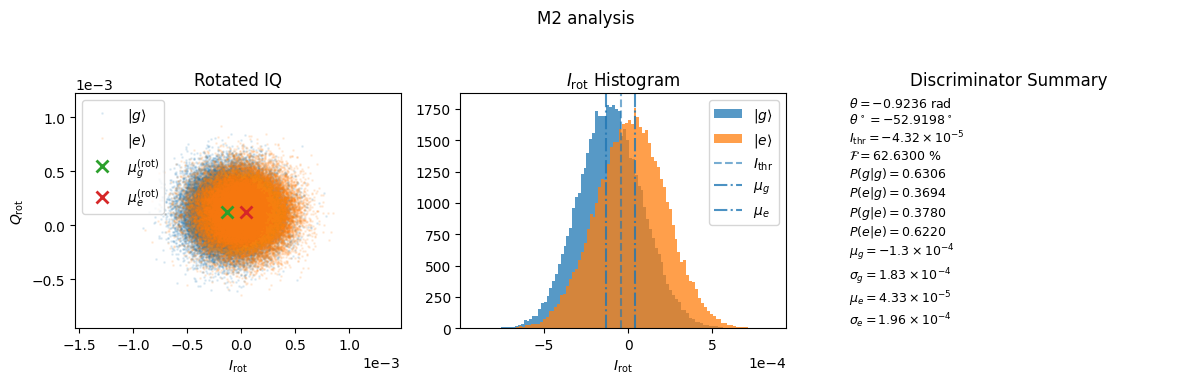

In [10]:
import importlib
import qubox_v2.experiments.calibration.readout as readout_mod
importlib.reload(readout_mod)

from qubox_v2.experiments.calibration.readout import ReadoutButterflyMeasurement
from qubox_v2.programs.macros.measure import measureMacro

bfly = ReadoutButterflyMeasurement(session)
result = bfly.run(
    r180="x180",
    k=3,
    M0_MAX_TRIALS=1000,
    update_measure_macro=True,
    n_samples=50000,
    use_stored_config=True,  # debug mode: prevent stale stored post-select config usage
)

analysis = bfly.analyze(result, update_calibration=True)
bfly.plot(analysis, show_histogram=True, show_discriminator=True)
print(f"F = {analysis.metrics.get('F', 0):.2%}")
print(f"Q = {analysis.metrics.get('Q', 0):.2%}")
print(f"V = {analysis.metrics.get('V', 0):.4f}")
print(f"F definition = {analysis.metrics.get('F_definition', 'N/A')}")

bfly_params = getattr(bfly, "_run_params", {})
print("\nButterfly prep-policy resolution:")
print(f"  policy: {bfly_params.get('post_sel_policy')}")
print(f"  source: {bfly_params.get('post_sel_source')}")
print(f"  kwargs: {bfly_params.get('post_sel_kwargs')}")

if "ge_fidelity_reference" in analysis.metrics:
    print(f"GE fidelity reference = {analysis.metrics['ge_fidelity_reference']:.2%}")
    print(f"GE fidelity definition = {analysis.metrics.get('ge_fidelity_definition', 'N/A')}")
    print(f"Delta (GE - F) = {analysis.metrics.get('fidelity_delta_GE_minus_F', float('nan')):.2%}")

print("\nReadout-state consistency:")
print(f"  state_match:  {analysis.metrics.get('readout_state_match')}")
print(f"  GE hash:      {analysis.metrics.get('readout_state_hash_ge')}")
print(f"  Butterfly hash:{analysis.metrics.get('readout_state_hash_butterfly')}")
print(f"  active threshold(measureMacro) = {measureMacro._ro_disc_params.get('threshold')}")

if "t01" in analysis.metrics:
    print(f"t01 = {analysis.metrics['t01']:.4f}")
    print(f"t10 = {analysis.metrics['t10']:.4f}")
if "Lambda_M_valid" in analysis.metrics:
    print(f"Lambda_M_valid = {analysis.metrics['Lambda_M_valid']}")

### 6.5 Full Readout Calibration Pipeline

Run the full state machine pipeline with explicit staged patch review and commit.
Stores all readout quality params in the cooldown-scoped calibration.

[INFO] 2026-02-25 00:43:43,973 qubox.experiments.calibration.readout: CalibrateReadoutFull pipeline starting
[INFO] 2026-02-25 00:43:43,974 qubox.experiments.calibration.readout: Step 1: Weight optimization
[INFO] 2026-02-25 00:43:43,994 qubox.experiments.calibration.readout: Weight optimization: ro_op='readout', n_avg=200000, persist=True
2026-02-25 00:43:44,133 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:43:44,225 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 199999/200000 [00:03<00:00, 57785.05it/s]

[INFO] 2026-02-25 00:43:47,761 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594150
No errors


[INFO] 2026-02-25 00:43:47,802 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-25 00:43:47,805 qubox.experiments.calibration.readout: Strict mode: optimized weight registration emitted as patch intent
[INFO] 2026-02-25 00:43:47,806 qubox.experiments.calibration.readout: Step 2: GE discrimination (n_samples=50000)
[INFO] 2026-02-25 00:43:47,806 qubox.experiments.calibration.readout: GE discrimination: n_samples=50000, measure_op='readout'
[INFO] 2026-02-25 00:43:47,843 qubox.experiments.calibration.readout: GE discrimination mapping: element=resonator op=readout pulse=readout_pulse available_ops=['const', 'readout']
2026-02-25 00:43:47,933 - qm - INFO     - Sending program to QOP for compilation
2026-02-25 00:43:47,996 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:10<00:00, 4951.18it/s]

[INFO] 2026-02-25 00:43:58,147 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594151
No errors


[INFO] 2026-02-25 00:43:58,219 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-25 00:44:00,190 qubox.experiments.calibration.readout: GE discrimination fidelity=69.79%, angle=0.2828 rad, threshold=-1.166e-05
[INFO] 2026-02-25 00:44:00,190 qubox.experiments.calibration.readout: Strict mode: rotated weight/macro updates emitted as patch intent
[INFO] 2026-02-25 00:44:00,191 qubox.experiments.calibration.readout: GE discrimination state pushed to measureMacro: hash=8ef223e2b4456059 thr=-1.1663e-05 angle=0.282805
[INFO] 2026-02-25 00:44:00,191 qubox.experiments.calibration.readout: Strict mode: runtime post-selection config refreshed from GE discrimination
[INFO] 2026-02-25 00:44:00,192 qubox.experiments.calibration.readout: Step 3: Butterfly measurement (n_shots=50000)
[INFO] 2026-02-25 00:44:00,206 qubox.experiments.calibration.readout: Butterfly measureMacro sync applied: element=resonator op=readout weights=['rot_cos', 'rot_sin', 'rot_m_sin']
[WARNING] 2026-02-25

Running Program...: 100%|█████████▉| 49999/50000 [00:04<00:00, 11707.85it/s]

[INFO] 2026-02-25 00:44:05,255 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594152
No errors


[INFO] 2026-02-25 00:44:05,579 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-25 00:44:05,586 qubox.experiments.calibration.readout: Butterfly metrics: F=0.5689, Q=0.9514, V=0.1378, t01=0.0000, t10=0.0973
[WARNING] 2026-02-25 00:44:05,587 qubox.experiments.calibration.readout: GE-vs-Butterfly fidelity mismatch: GE=0.6979, F=0.5689, delta=12.90%
[INFO] 2026-02-25 00:44:05,587 qubox.experiments.calibration.readout: Butterfly readout-quality updates emitted as patch ops
[INFO] 2026-02-25 00:44:05,587 qubox.experiments.calibration.readout: T1 decay correction: readout=400 ns, T1=7.5 us, factor=0.9482
Fidelity of M1: 0.5689
QND-ness of M1: 0.9514
Visibility of M1: 0.1378

Single-shot outcome probabilities P(m_k | state_i):
|    |   Ground (g) |   Excited (e) |
|:---|-------------:|--------------:|
| m0 |       1.0000 |        0.9975 |
| m1 |       0.7709 |        0.3668 |
| m2 |       0.7754 |        0.3534 |

Measurement confusion matrix Lambda_M = P(m1 | state_i):


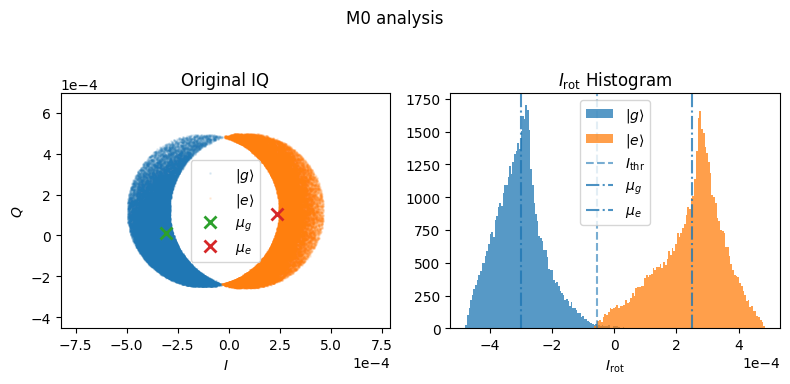

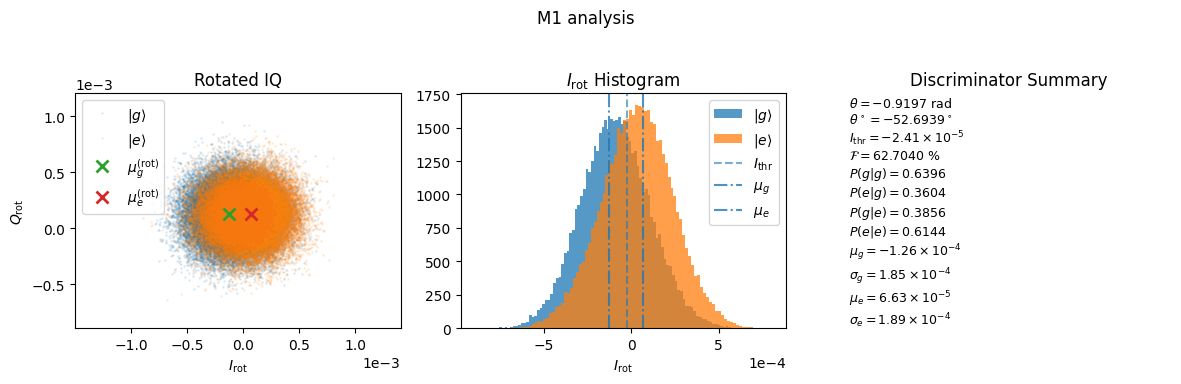

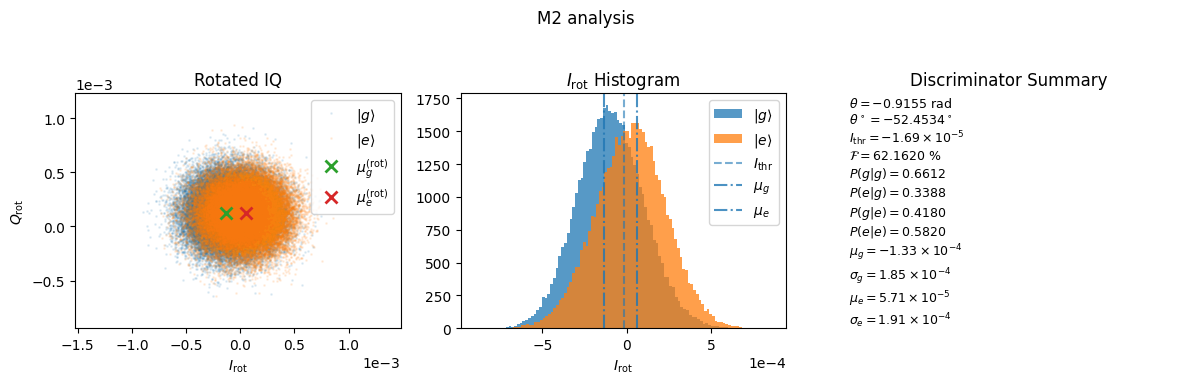

In [12]:
import importlib
import qubox_v2.experiments.calibration.readout as readout_mod
importlib.reload(readout_mod)

from qubox_v2.experiments.calibration.readout import (
    CalibrationReadoutFull,
    ReadoutConfig,
)
from qubox_v2.programs.macros.measure import measureMacro

LEGACY_BLOB_K = 3.0
LEGACY_M0_MAX_TRIALS = 1000

readoutConfig = ReadoutConfig(
    measure_op="readout",
    drive_frequency=attr.ro_fq,
    ro_el=attr.ro_el,
    r180="x180",
    n_avg_weights=200_000,
    n_samples=50_000,
    n_shots_butterfly=50_000,
    skip_weights_optimization=False,
    persist_weights=True,
    update_weights=True,
    update_threshold=True,
    rotation_method="optimal",
    weight_extraction_method="legacy_ge_diff_norm",
    histogram_fitting="two_state_discriminator",
    threshold_extraction="legacy_discriminator",
    overwrite_policy="override",
    blob_k_g=LEGACY_BLOB_K,
    blob_k_e=LEGACY_BLOB_K,
    M0_MAX_TRIALS=LEGACY_M0_MAX_TRIALS,
    save_to_config=True,
    save_calibration_json=True,
    save_calibration_db=False,
    save_measure_config=True,
    save_session_state=False,
    display_analysis=False,
    ge_kwargs={
        "auto_update_postsel": True,
        "apply_rotated_weights": True,
        "persist": True,
    },
    bfly_kwargs={
        "update_measure_macro": True,
        "show_analysis": True,
    },
)

cal = CalibrationReadoutFull(session)
ro_pipeline_result = cal.run(readoutConfig=readoutConfig)
ro_pipeline_analysis = cal.analyze(ro_pipeline_result, update_calibration=True)

ge_stage = ro_pipeline_analysis.metadata.get("ge_analysis")
bfly_stage = ro_pipeline_analysis.metadata.get("bfly_analysis")

ge_fid_raw = float(ro_pipeline_analysis.metrics.get("ge_fidelity", float("nan")))
ge_fid_frac = ge_fid_raw / 100.0 if np.isfinite(ge_fid_raw) and ge_fid_raw > 1.0 else ge_fid_raw
ge_fid_pct = ge_fid_frac * 100.0 if np.isfinite(ge_fid_frac) else float("nan")

bfly_F = float(ro_pipeline_analysis.metrics.get("bfly_F", float("nan")))
ge_minus_F = ge_fid_frac - bfly_F if (np.isfinite(ge_fid_frac) and np.isfinite(bfly_F)) else float("nan")

weights_mode = "optimized" if not readoutConfig.skip_weights_optimization else "base"
print("Readout calibration pipeline complete.")
print(f"Weight mode = {weights_mode}")
print(f"GE fidelity = {ge_fid_pct:.2f}%  ({ge_fid_frac:.4f} frac, raw={ge_fid_raw:.4g})")
print(f"GE angle    = {ro_pipeline_analysis.metrics.get('ge_angle', 0):.6f} rad")
print(f"GE thr      = {ro_pipeline_analysis.metrics.get('ge_threshold', 0):.6g}")
print(f"F = {ro_pipeline_analysis.metrics.get('bfly_F', 0):.4f}, Q = {ro_pipeline_analysis.metrics.get('bfly_Q', 0):.4f}, V = {ro_pipeline_analysis.metrics.get('bfly_V', 0):.4f}")
print(f"GE/100 - F  = {ge_minus_F:.4f}")
print(f"Lambda_M_valid = {ro_pipeline_analysis.metrics.get('bfly_Lambda_M_valid', None)}")
print(f"acceptance_rate = {ro_pipeline_analysis.metrics.get('bfly_acceptance_rate', float('nan'))}")
print(f"average_tries   = {ro_pipeline_analysis.metrics.get('bfly_average_tries', float('nan'))}")
print(f"readout_duration_ns   = {ro_pipeline_analysis.metrics.get('bfly_readout_duration_ns', float('nan'))}")
print(f"readout_duration_clks = {ro_pipeline_analysis.metrics.get('bfly_readout_duration_clks', float('nan'))}")
print(f"T1_decay_factor       = {ro_pipeline_analysis.metrics.get('bfly_T1_decay_factor', float('nan'))}")
print(f"measureMacro confusion loaded: {measureMacro._ro_quality_params.get('confusion_matrix') is not None}")

fq_entry = session.calibration.get_frequencies(attr.qb_el)
cal_qb_fq = None if fq_entry is None else getattr(fq_entry, "qubit_freq", None)
attr_qb_fq = getattr(attr, "qb_fq", None)
print("\nQubit frequency binding check:")
print(f"  calibration frequencies.{attr.qb_el}.qubit_freq = {cal_qb_fq}")
print(f"  runtime attr.qb_fq                               = {attr_qb_fq}")
if cal_qb_fq is not None and attr_qb_fq is not None:
    print(f"  delta (attr - calibrated)                        = {float(attr_qb_fq) - float(cal_qb_fq)} Hz")

if bfly_stage is not None:
    cm = bfly_stage.metrics.get("confusion_matrix", None)
    tm = bfly_stage.metrics.get("transition_matrix", None)
else:
    cm = None
    tm = None

if cm is not None:
    print("\nButterfly confusion matrix Lambda_M:")
    try:
        print(cm.to_markdown(floatfmt=".4f"))
    except Exception:
        print(cm)
if tm is not None:
    print("\nButterfly transition matrix T:")
    try:
        print(tm.to_markdown(floatfmt=".4f"))
    except Exception:
        print(tm)

ro_pipeline_summary = {
    "readoutConfig": readoutConfig,
    "result": ro_pipeline_result,
    "analysis": ro_pipeline_analysis,
    "parity": {
        "ge_fidelity_frac": ge_fid_frac,
        "F": bfly_F,
        "ge_minus_F": ge_minus_F,
    },
}

### 6.6 Readout Calibration Artifacts

Save all readout calibration metrics and state machine histories as
session artifacts. Validates persistence to cooldown-scoped paths.

[INFO] 2026-02-24 23:50:58,001 qubox.calibration.store: Calibration saved to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[INFO] 2026-02-24 23:50:58,048 qubox.experiments.session: Saved pulse manager state to E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json
2026-02-24 23:50:58,376 - qm - INFO     - Sending program to QOP for compilation
2026-02-24 23:50:59,122 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:10<00:00, 467.34it/s]

[INFO] 2026-02-24 23:51:09,890 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622594079
No errors


[INFO] 2026-02-24 23:51:09,920 qubox.hardware.program_runner: Job halted successfully.


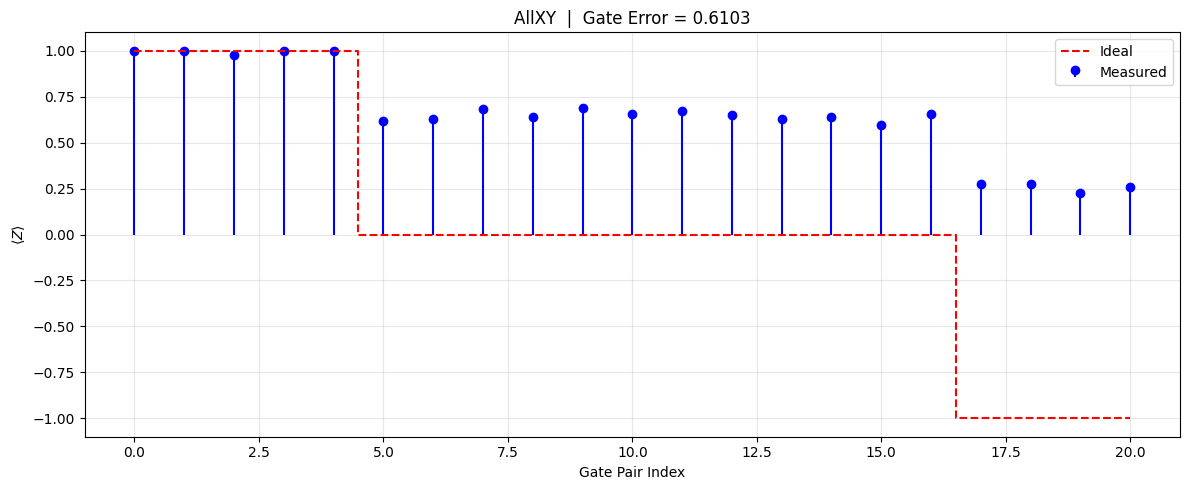

=== Calibration Summary ===
g_pi (ref_r180): 0.998519
Primitive pulse amplitudes:
  x180 : None
  y180 : None
  x90  : None
  xn90 : None
  y90  : None
  yn90 : None
GE fidelity: 0.7031000000000001
Rotation angle: 0.19742133101085552
F=0.5732200000000001, Q=0.9298688882818901, V=0.14644000000000004
Confusion matrix:
[[0.7659, 0.30738], [0.2341, 0.69262]]
Transition matrix:
[[0.9944176604922609, 0.05358200118413254], [0.005582339507739094, 0.9464179988158674]]
ALLXY observable: sigma_z
ALLXY correction applied: True
ALLXY state mapping: {'g': 1.0, 'e': -1.0}
Final mapping: +1 -> |g>, -1 -> |e>
measureConfig persisted to: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\measureConfig.json


In [11]:
import importlib
from pathlib import Path
import qubox_v2.experiments.calibration.gates as gates_mod
importlib.reload(gates_mod)
from qubox_v2.experiments.calibration.gates import AllXY
from qubox_v2.programs.macros.measure import measureMacro

# Persist readout + pulse calibration artifacts (cooldown-scoped)
session.calibration.save()
session.save_pulses()
measure_cfg_path = Path(session.experiment_path) / "config" / "measureConfig.json"
measure_cfg_path.parent.mkdir(parents=True, exist_ok=True)
measureMacro.save_json(str(measure_cfg_path))

# Reload measureMacro from disk to validate persistence path
measureMacro.load_json(str(measure_cfg_path))

# Run ALLXY as post-readout sanity check
allxy = AllXY(session)
allxy_result = allxy.run(n_avg=5000)
allxy_analysis = allxy.analyze(allxy_result)
allxy.plot(allxy_analysis)

cm = measureMacro._ro_quality_params.get("confusion_matrix", None)
tm = measureMacro._ro_quality_params.get("transition_matrix", None)

print("=== Calibration Summary ===")
print(f"g_pi (ref_r180): {float(globals().get('rabi_g_pi', float('nan'))):.6f}")

primitive_ops = ["x180", "y180", "x90", "xn90", "y90", "yn90"]
print("Primitive pulse amplitudes:")
for op_name in primitive_ops:
    pcal = session.calibration.get_pulse_calibration(op_name)
    print(f"  {op_name:5s}: {getattr(pcal, 'amplitude', None)}")

if "ro_pipeline_analysis" in globals():
    _m = ro_pipeline_analysis.metrics
    print(f"GE fidelity: {_m.get('ge_fidelity')}")
    print(f"Rotation angle: {_m.get('ge_angle')}")
    print(f"F={_m.get('bfly_F')}, Q={_m.get('bfly_Q')}, V={_m.get('bfly_V')}")

print("Confusion matrix:")
print(cm)
print("Transition matrix:")
print(tm)
print(f"ALLXY observable: {allxy_analysis.metrics.get('observable')}")
print(f"ALLXY correction applied: {allxy_analysis.metrics.get('used_confusion_correction')}")
print(f"ALLXY state mapping: {allxy_analysis.metrics.get('state_mapping')}")
print("Final mapping: +1 -> |g>, -1 -> |e>")
print(f"measureConfig persisted to: {measure_cfg_path}")

## 7. SPA Benchmarking

### 7.1 SPA Flux Optimization

Sweep DC flux bias with SPA-enhanced readout to find optimal flux point.

In [ ]:
spa_flux = SPAFluxOptimization(session)
result = spa_flux.run(
    dc_list=np.linspace(-0.5, 0.5, 51),
    sample_fqs=np.linspace(8.5e9, 8.7e9, 21),
    n_avg=1000,
)

analysis = spa_flux.analyze(result)
spa_flux.plot(analysis)
print(f"Best DC = {analysis.metrics.get('best_dc', 'N/A'):.4f} V")
print(f"Best freq = {analysis.metrics.get('best_freq', 0) / 1e6:.2f} MHz")

### 7.2 SPA Pump Frequency Optimization

2D sweep of pump power and detuning to optimize SPA readout fidelity.

In [ ]:
spa_pump = SPAPumpFrequencyOptimization(session)
# result = spa_pump.run(
#     readout_op="readout",
#     drive_frequency=attr.qb_fq,
#     pump_powers=np.linspace(0.1, 1.0, 10),
#     pump_detunings=np.linspace(-5e6, 5e6, 21),
#     r180="x180",
#     samples_per_run=25000,
# )
# analysis = spa_pump.analyze(result)
# spa_pump.plot(analysis)
# print(f"Best pump power = {analysis.metrics.get('best_pump_power', 'N/A')}")
# print(f"Best pump detuning = {analysis.metrics.get('best_pump_detuning', 'N/A')}")

### 7.3 Register Storage Cavity Pulse Definitions

**Required** before running any storage cavity experiments.

Registers:
- `const_alpha` â€” constant displacement pulse on the storage element
- `sel_x180` and derived selective rotations (`sel_y180`, `sel_x90`, etc.) â€”
  Kaiser-windowed selective pi pulse for Fock-number-resolved qubit control

In [ ]:
from qubox_v2.tools.waveforms import kaiser_pulse_waveforms
from qubox_v2.tools.generators import register_rotations_from_ref_iq

pm = session.pulse_mgr

# ---- const_alpha: constant displacement pulse on storage ----
alpha_len = 48   # ns (must be >= 16, divisible by 4)
alpha_amp = 0.019580
b_alpha = 1.0

pm.create_control_pulse(
    element=attr.st_el,
    op="const_alpha",
    length=alpha_len,
    I_samples=[alpha_amp] * alpha_len,
    Q_samples=[0.0] * alpha_len,
    override=True,
    persist=False,
)

# Store displacement reference for ensure_displacement_ops
session._displacement_ref = {
    "coherent_amp": alpha_amp,
    "coherent_len": alpha_len,
    "b_alpha": b_alpha,
}

print(f"const_alpha registered: len={alpha_len}, amp={alpha_amp}, b_alpha={b_alpha}")

# ---- sel_x180: Kaiser-windowed selective pi pulse ----
sel_rlen = 1000   # ns
sel_kaiser_amp = 0.0013420737712946228
sel_beta = 7.967
anh = float(getattr(attr, "anharmonicity", 0) or -200e6)

sel_I, sel_Q = kaiser_pulse_waveforms(
    amplitude=sel_kaiser_amp,
    length=sel_rlen,
    beta=sel_beta,
    detuning=0.0,
    subtracted=True,
    alpha=0.0,
    anharmonicity=anh,
)

# Register ref + all derived rotations (sel_x180, sel_y180, sel_x90, etc.)
sel_ops = register_rotations_from_ref_iq(
    pm,
    ref_I=sel_I,
    ref_Q=sel_Q,
    element=attr.qb_el,
    prefix="sel_",
    rotations="all",
    make_r0=False,
    override=True,
    persist=False,
)

session.burn_pulses()

print(f"sel_x180 registered: len={sel_rlen}, amp={sel_kaiser_amp}, beta={sel_beta}")
print(f"Selective rotation ops: {list(sel_ops.keys())}")

## 8. Storage Cavity

### 8.1 Storage Spectroscopy

Sweep storage cavity frequency to locate resonance.

In [ ]:
st_spec = StorageSpectroscopy(session)
result = st_spec.run(
    disp="const_alpha",
    rf_begin=5200 * u.MHz,
    rf_end=5280 * u.MHz,
    df=200 * u.kHz,
    storage_therm_time=500,
    n_avg=50,
)

analysis = st_spec.analyze(result, update_calibration=True)
st_spec.plot(analysis)
print(f"f_storage = {analysis.metrics['f_storage'] / 1e6:.4f} MHz")
print(f"kappa = {analysis.metrics['kappa'] / 1e3:.1f} kHz")

### 8.1b Storage Spectroscopy (Orchestrator Pipeline)

Run via the Artifact -> CalibrationResult -> Patch -> Orchestrator flow.

In [ ]:
st_spec = StorageSpectroscopy(session)
st_center = float(getattr(attr, "st_fq", attr.qb_fq))
st_cycle = orch.run_analysis_patch_cycle(
    st_spec,
    run_kwargs={
        "disp": "const_alpha",
        "rf_begin": (st_center - 5 * u.MHz),
        "rf_end": (st_center + 5 * u.MHz),
        "df": 200 * u.kHz,
        "storage_therm_time": int(getattr(attr, "qb_therm_clks", 0)),
        "sel_r180": "sel_x180",
        "n_avg": 1000,
    },
    analyze_kwargs={"update_calibration": True},
    apply=False,
    persist_artifact=True,
)

st_result = orch._run_result_from_artifact(st_cycle["artifact"])
st_analysis = st_spec.analyze(st_result, update_calibration=False)
st_spec.plot(st_analysis)
print(f"storage f0 = {st_cycle['calibration_result'].params.get('f_storage_MHz', float('nan')):.4f} MHz")
print("Patch preview:")
for item in st_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(st_cycle["patch"], dry_run=False)

### 8.2 Number Splitting Spectroscopy

Resolve photon-number-dependent qubit frequency shifts.

In [ ]:
from qm.qua import wait

def prep_vacuum():
    """Explicit no-op preparation for notebook-driven workflows."""
    wait(1)

nsplit = NumSplittingSpectroscopy(session)
result = nsplit.run(
    rf_centers=[attr.qb_fq],
    rf_spans=[10 * u.MHz],
    df=100 * u.kHz,
    state_prep=prep_vacuum,
    n_avg=500,
)

analysis = nsplit.analyze(result)
nsplit.plot(analysis)
print(analysis.metrics)

### 8.3 Storage Chi Ramsey

Measure dispersive coupling chi via Ramsey interferometry.

In [ ]:
chi_ramsey = StorageChiRamsey(session)
result = chi_ramsey.run(
    fock_fq=attr.qb_fq,
    delay_ticks=np.arange(4, 2000, 10),
    disp_pulse="const_alpha",
    x90_pulse="x90",
    n_avg=20,
)

analysis = chi_ramsey.analyze(result, update_calibration=True,
                              p0=[0.5, 0.5, 35000, 0.1, 0.0028, 400])
chi_ramsey.plot(analysis)
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")
print(f"nbar = {analysis.metrics.get('nbar', 0):.2f}")

### 8.4 Fock-Resolved Spectroscopy

Probe qubit spectroscopy conditioned on Fock number.

In [ ]:
fock_spec = FockResolvedSpectroscopy(session)
result = fock_spec.run(
    probe_fqs=np.linspace(attr.qb_fq - 5e6, attr.qb_fq + 5e6, 101),
    state_prep=prep_vacuum,
    n_avg=20,
)

analysis = fock_spec.analyze(result)
fock_spec.plot(analysis)
print(analysis.metrics)

### 8.4b Register Displacement Pulses for Fock-Resolved Experiments

**REQUIRED** before running Fock-resolved T1, Ramsey, or Power Rabi.

In [ ]:
from qubox_v2.tools.generators import ensure_displacement_ops

n_fock = 3

disp_ref = getattr(session, '_displacement_ref', None) or session.get_displacement_reference()
coherent_amp = disp_ref.get("coherent_amp", None)
coherent_len = disp_ref.get("coherent_len", None)
b_alpha = disp_ref.get("b_alpha", None)

created = ensure_displacement_ops(
    session.pulse_mgr,
    element=attr.st_el,
    n_max=n_fock,
    coherent_amp=coherent_amp,
    coherent_len=coherent_len,
    b_alpha=b_alpha,
)

session.burn_pulses()

print(f"Displacement refs: amp={coherent_amp}, len={coherent_len}, alpha={b_alpha}")
print(f"Registered {len(created)} displacement ops on '{attr.st_el}':")
for name, (I, Q) in created.items():
    print(f"  {name}: len={len(I)}, max_I={I.max():.4f}, max_Q={Q.max():.4f}")

### 8.5 Fock-Resolved T1

Measure T1 in individual Fock manifolds.

In [ ]:
fock_t1 = FockResolvedT1(session)

n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_t1.run(
     fock_fqs=fock_fqs,
     fock_disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=200,
     n_avg=20,
)
analysis = fock_t1.analyze(result)
fock_t1.plot(analysis)
for key, val in analysis.metrics.items():
     if key.startswith("T1_fock_"):
         print(f"{key} = {val / 1e3:.2f} us")

### 8.6 Fock-Resolved Ramsey

Measure T2 in individual Fock manifolds.

In [ ]:
fock_ramsey = FockResolvedRamsey(session)

n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_ramsey.run(
     fock_fqs=fock_fqs,
     detunings=[0.2e6],
     disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=100,
     n_avg=20,
)
analysis = fock_ramsey.analyze(result)
fock_ramsey.plot(analysis)
print(analysis.metrics)

### 8.7 Fock-Resolved Power Rabi

Calibrate selective pi pulses per Fock manifold.

In [ ]:
fock_rabi = FockResolvedPowerRabi(session)
# fock_fqs = [...]  # From NumSplittingSpectroscopy results
# result = fock_rabi.run(
#     fock_fqs=fock_fqs,
#     gains=np.linspace(0, 1.5, 50),
#     sel_qb_pulse="sel_x180",
#     disp_n_list=["disp_n0", "disp_n1", "disp_n2"],
#     n_avg=2000,
# )
# analysis = fock_rabi.analyze(result)
# fock_rabi.plot(analysis)
# for key, val in analysis.metrics.items():
#     if key.startswith("g_pi_fock_"):
#         print(f"{key} = {val:.4f}")

## 9. Quantum State Tomography

### 9.1 Qubit State Tomography

Three-axis measurement to reconstruct the qubit Bloch vector.

In [ ]:
from qm.qua import *

def prep_x_plus():
    """Prepare |+x> state."""
    play("x90", attr.qb_el)

tomo = QubitStateTomography(session)
result = tomo.run(
    state_prep=prep_x_plus,
    n_avg=10000,
)

analysis = tomo.analyze(result)
tomo.plot(analysis)
print(f"sx = {analysis.metrics.get('sx', 0):.3f}")
print(f"sy = {analysis.metrics.get('sy', 0):.3f}")
print(f"sz = {analysis.metrics.get('sz', 0):.3f}")
print(f"Purity = {analysis.metrics.get('purity', 0):.3f}")

### 9.2 Wigner Tomography

Reconstruct the Wigner function of the storage cavity state.

In [ ]:
wigner = StorageWignerTomography(session)
# result = wigner.run(
#     gates=[...],
#     x_vals=np.linspace(-3, 3, 41),
#     p_vals=np.linspace(-3, 3, 41),
#     n_avg=500,
# )
# analysis = wigner.analyze(result)
# wigner.plot(analysis)
# print(f"W_min = {analysis.metrics.get('W_min', 0):.3f}")
# print(f"W_max = {analysis.metrics.get('W_max', 0):.3f}")
# print(f"Negativity = {analysis.metrics.get('negativity', 0):.3f}")

### 9.3 SNAP Optimization

Optimize SNAP gate angles using Fock-resolved state tomography.

In [ ]:
snap = SNAPOptimization(session)
# result = snap.run(
#     snap_gate=...,
#     disp1_gate=...,
#     fock_probe_fqs=[...],
#     n_avg=500,
# )
# analysis = snap.analyze(result)
# snap.plot(analysis)
# print(analysis.metrics)

## 10. Session Verification & Summary

### 10.1 Waveform Regression Check

Verify that PulseFactory produces deterministic, correct waveforms.

In [ ]:
from qubox_v2.verification.waveform_regression import run_all_checks

wf_results = run_all_checks()
passed = sum(1 for r in wf_results if r.passed)
total = len(wf_results)
print(f"Waveform regression: {passed}/{total} passed")

for r in wf_results:
    if not r.passed:
        print(r)

if passed == total:
    print("All waveform regression checks PASSED.")
else:
    print(f"WARNING: {total - passed} waveform regression check(s) failed.")

### 10.2 Session Summary & Artifact Finalization

Print context, build hash, all calibrations committed, and save the
final session report. All artifacts are written to cooldown-scoped paths.

In [ ]:
import datetime

print("=" * 60)
print("  SESSION SUMMARY (Context Mode)")
print("=" * 60)
print(f"  Sample ID:      {ctx.sample_id}")
print(f"  Cooldown ID:    {ctx.cooldown_id}")
print(f"  Wiring Rev:     {ctx.wiring_rev}")
print(f"  Config Hash:    {ctx.config_hash}")
print(f"  Build hash:     {ss.build_hash}")
print(f"  Git commit:     {ss.git_commit or 'unknown'}")
print(f"  Timestamp:      {ss.build_timestamp}")
print(f"  Experiment Path: {session.experiment_path}")
print()

# Calibration file location
print(f"  Calibration file: {session.calibration.path}")
print(f"  Calibration version: {session.calibration.data.version}")
cal_ctx = session.calibration.data.context
if cal_ctx:
    print(f"  Calibration sample_id:   {cal_ctx.sample_id}")
    print(f"  Calibration cooldown_id: {cal_ctx.cooldown_id}")
    print(f"  Calibration wiring_rev:  {cal_ctx.wiring_rev}")
print()

# Collect calibration state machines
all_sms = []
for name in ["sm_rabi", "sm_drag", "sm_readout"]:
    sm_obj = globals().get(name)
    if sm_obj is None:
        continue
    info = sm_obj.summary()
    all_sms.append(info)
    state_str = info["state"]
    committed = state_str == "committed"
    print(f"  {info['experiment']:20s}  {state_str:20s}  "
          f"{'COMMITTED' if committed else 'not committed'}")

# Waveform regression
print(f"\n  Waveform regression:  {passed}/{total} passed")

# Schema validation
n_valid = sum(1 for r in schema_results if r.valid)
print(f"  Schema validation:    {n_valid}/{len(schema_results)} passed")

print()

# Save session summary report
report_lines = [
    f"# Session Report (Context Mode)",
    f"",
    f"- Sample ID: {ctx.sample_id}",
    f"- Cooldown ID: {ctx.cooldown_id}",
    f"- Wiring Rev: {ctx.wiring_rev}",
    f"- Config Hash: {ctx.config_hash}",
    f"- Build hash: {ss.build_hash}",
    f"- Git commit: {ss.git_commit or 'unknown'}",
    f"- Timestamp:  {ss.build_timestamp}",
    f"- Report generated: {datetime.datetime.now().isoformat()}",
    f"",
    f"## Calibration State Machines",
    f"",
]
for info in all_sms:
    report_lines.append(f"- **{info['experiment']}**: {info['state']} "
                        f"({info['transitions']} transitions, "
                        f"has_patch={info['has_patch']})")
report_lines += [
    f"",
    f"## Verification",
    f"",
    f"- Waveform regression: {passed}/{total} passed",
    f"- Schema validation: {n_valid}/{len(schema_results)} passed",
]

am.save_report("session_summary", "\n".join(report_lines))

# List all artifacts
print("Artifacts:")
for artifact in am.list_artifacts():
    if artifact.is_file():
        print(f"  {artifact.relative_to(am.root)}")

print()
print("=" * 60)
from qubox_v2.core.artifact_manager import cleanup_artifacts
removed = cleanup_artifacts(str(session.experiment_path), keep_latest=5, current_hash=ss.build_hash)
if removed:
    print(f"  Cleaned up {len(removed)} old artifact directories.")
print("  Done.")

## 11. Context Mismatch Protection Demo

If you try to load calibration from a different sample or with a mismatched
wiring revision, the system raises `ContextMismatchError` (in strict mode)
or logs a warning (in non-strict mode).

In [ ]:
from qubox_v2.core.errors import ContextMismatchError
from qubox_v2.core.experiment_context import ExperimentContext
from qubox_v2.calibration.store import CalibrationStore

# Simulate a mismatched context
wrong_ctx = ExperimentContext(
    sample_id="different_sample",
    cooldown_id=COOLDOWN_ID,
    wiring_rev="00000000",
)

try:
    bad_store = CalibrationStore(
        session.calibration.path,
        context=wrong_ctx,
        strict_context=True,
    )
except ContextMismatchError as e:
    print(f"BLOCKED: Context mismatch detected!\n  {e}")
else:
    print("No mismatch (calibration file may not have a context block yet)")

print(f"\nActive context:  sample={ctx.sample_id}, cooldown={ctx.cooldown_id}")
print(f"Wrong context:   sample={wrong_ctx.sample_id}, cooldown={wrong_ctx.cooldown_id}")

## 12. Utility: Continuous-Wave Output

Drive a target element continuously for diagnostics such as
spectrum analyser alignment or mixer leakage checks.

In [ ]:
from qubox_v2.programs.builders.utility import continuous_wave

target_element = attr.qb_el
cw_pulse = "const"
cw_gain = 0.5
truncate_clks = 250

cw_prog = continuous_wave(
    target_el=target_element,
    pulse=cw_pulse,
    gain=cw_gain,
    truncate_clks=truncate_clks,
)

print(f"Starting CW output on '{target_element}'")
print(f"  pulse      = {cw_pulse}")
print(f"  gain       = {cw_gain}")
print(f"  truncate   = {truncate_clks} clks ({truncate_clks * 4} ns)")
print(f"  This program runs in an INFINITE LOOP.")
print(f"  To stop:  job.halt()")

job = session.hw.qm.execute(cw_prog)
print(f"\nJob started: {job.id}")
print("Run 'job.halt()' in the next cell to stop.")

In [ ]:
# --- Stop CW output ---
job.halt()
print("CW output halted.")

## 13. Close Session

In [ ]:
session.close()
print("Session closed.")
print(f"All calibrations saved to cooldown-scoped path: {session.experiment_path}")

---

## Static Audit Report (2026-02-24)

Generated by static inspection — no hardware execution performed.

### Fixes Applied

| # | Cell | Issue | Fix |
|---|------|-------|-----|
| 1 | 69 |  used nonexistent dict keys; always returned  | Replaced with  access |
| 2 | 107 |  for state-machine lookup — code injection risk | Replaced with  + None guard |

### Structural Changes

| Deliverable | Description | Cells affected |
|---|---|---|
| A1 | Merged Sections 1+2+2.1 into idempotent Section 1 | 0-7 (replaced), 8-10 (deleted) |
| A2 | Dedicated readout override cell (Section 1.2) | 6-7 (new) |
| B | Mixer cal: auto-cal (2.0) + manual UX (2.1) + manual run (2.2) | 8-14 (restructured) |
| D | Rotation cal: verify run (5.1d), verify analysis (5.1e), broadcast knobs (5.1f) | 46-51 (inserted) |
| Renumber | Sections 3-14 renumbered to 2-13 | All markdown headers |

### NEEDS_RUN Items

Cells requiring QOP/instrument connection before execution:

| Cell | Section | What |
|------|---------|------|
| 3 | 1. Setup |  — QM health check |
| 10 | 2.0 Auto Cal |  |
| 14 | 2.2 Manual Cal | SA124B manual mixer calibration |
| 17 | 3.1 Readout Trace |  |
| 19 | 3.2 Resonator Spec |  |
| 21 | 3.3 Power Spec |  |
| 23 | 3.4 Spec X180 |  |
| 26 | 4.1 Qubit Spec |  |
| 28 | 4.2 Power Rabi |  |
| 30 | 4.3 Temporal Rabi |  |
| 32 | 4.4 T1 |  |
| 34 | 4.5 T2 Ramsey |  |
| 36 | 4.6 T2 Echo |  |
| 41 | 5.1 DRAG |  |
| 45 | 5.1c Pulse-Train |  |
| 47 | 5.1d Verify Run |  with corrected gate |
| 53 | 5.2 AllXY |  |
| 56 | 5.3 RB |  |
| 59 | 6.1 IQ Blob |  |
| 61 | 6.2 Weight Opt |  |
| 63 | 6.3 GE Discrim |  |
| 65 | 6.4 Butterfly |  |
| 67 | 6.5 Full RO Pipeline |  |
| 69 | 6.6 RO Artifacts |  (post-RO sanity check) |
| 72 | 7.1 SPA Flux |  |
| 79 | 8.1 Storage Spec |  |
| 81 | 8.1b Storage Orch |  |
| 83 | 8.2 Num Splitting |  |
| 85 | 8.3 Chi Ramsey |  |
| 87 | 8.4 Fock Spec |  |
| 91 | 8.5 Fock T1 |  |
| 93 | 8.6 Fock Ramsey |  |
| 98 | 9.1 Qubit Tomo |  |
| 111 | 12. CW Output |  |

### Notes

- **Cell 3**: References  as a seed path for initial sample creation.
  This is inside an idempotent guard () and will not
  execute when the sample already exists. Benign but noted.
- **All stale cell outputs cleared** — cells must be re-run to regenerate outputs.
- **No schema or API mismatches detected** in static analysis of import paths,
  method signatures, and field names.


---

## Summary

All experiment classes follow the unified `run() -> analyze() -> plot()` protocol:

```python
exp = ExperimentClass(session)
result = exp.run(...)
analysis = exp.analyze(result, update_calibration=True)
exp.plot(analysis)
print(analysis.metrics)
```

### Context Mode vs Legacy Mode

| Feature | Context Mode (this notebook) | Legacy Mode |
|---------|-----|------|
| Session init | `SessionManager(sample_id=..., cooldown_id=...)` | `SessionManager("./seq_1_device")` |
| Calibration scoping | Per-cooldown directory | Single flat directory |
| Stale-cal protection | `ContextMismatchError` on sample/wiring mismatch | None |
| Config paths | Sample-level + cooldown-level separation | All in one `config/` |
| Artifact paths | `cooldowns/<id>/artifacts/` | `artifacts/` |
| `session.context` | `ExperimentContext(sample_id, cooldown_id, ...)` | `None` |

### Switching Cooldowns

To start a new cooldown with the same sample:

```python
registry.create_cooldown("post_cavity_sample_A", "cd_2025_03_15")
session = SessionManager(
    sample_id="post_cavity_sample_A",
    cooldown_id="cd_2025_03_15",
    registry_base=Path("E:/qubox"),
    qop_ip="10.157.36.68",
)
session.open()
# Fresh calibrations â€” no risk of stale data from previous cooldown
```

### Architecture Integration

| Component | Where | Purpose |
|---|---|---|
| `SampleRegistry` | Section 1 | Sample + cooldown directory management |
| `ExperimentContext` | Section 1 | Immutable context identity (sample + cooldown + wiring) |
| `CalibrationContext` | Section 1 | Context block stamped in calibration.json |
| `ContextMismatchError` | Section 11 | Prevents stale-calibration reuse |
| `SessionState` | Section 1.1 | Immutable config snapshot with SHA-256 build hash |
| `CalibrationOrchestrator` | All cal sections | Artifact -> Patch -> Commit lifecycle |
| `CalibrationStateMachine` | Section 5.1b | Lifecycle enforcement for calibration commits |
| `ArtifactManager` | Section 10.2 | Build-hash keyed artifact storage |